# 05 — BERTopic Pipeline untuk wondr by BNI

Topic modeling temporal terhadap keluhan pengguna **wondr by BNI** menggunakan **BERTopic** dengan **IndoBERT** embeddings, dilanjutkan dengan validasi cosine similarity (Section 9) dan uji tren Mann-Kendall (Section 10).

## Pipeline Overview

| Section | Tahap | Output utama |
|---------|-------|--------------|
| 0 | Setup (imports + autoreload) | — |
| 1 | Load data + generate IndoBERT embeddings (cached) | `data/embeddings/wondr_embeddings.npy` |
| 2 | Sensitivity analysis 3×3 grid (UMAP × HDBSCAN) | Grid table |
| 3 | Pick winner via c_v coherence | Winner params |
| 4 | Validate winner with c_npmi | Coherence comparison |
| 5 | Final Phase A model | Locked config |
| 6 | Topic inspection (Phase A output) | Top words + rep docs |
| 7 | Phase B (stopword refinement) + Phase C (manual merge) | `data/models/wondr_phase_c/` (13 topics) |
| 8 | DTM monthly analysis | Frequency + proportion plots, 3 summary tables |
| 9 | Cosine similarity D1 (embedding) + D2 (c-TF-IDF) | 4 plots, comparison table |
| 9.5 | Threshold sensitivity check | Histogram + reklasifikasi pattern |
| 10 | Mann-Kendall + Sen's slope + FDR-BH | 4 plots, 3 tables |
| 10.5 | T11 numerical edge case fix | Practically stable flag |

## Output Locations

- **Models:** `data/models/wondr_phase_c/` (safetensors)
- **Tabel:** `outputs/tables/wondr_*.csv`
- **Figures:** `outputs/figures/wondr/*.png`
- **DTM intermediate:** `data/processed/wondr_topics_over_time.pkl`

## Catatan untuk Kernel Reload

Section 8 dan setelahnya bisa dijalankan dari fresh kernel (tanpa run Section 0-7 dulu) lewat **Section 8.0 — Kernel Reload Sequence**. Berguna kalau lagi iterate di tahap analysis tanpa harus retrain BERTopic.

## Section 0 — Setup

### 0.1 Imports + autoreload

`autoreload 2` memastikan edit pada modul `utils/` ke-pick up tanpa restart kernel. Wajib untuk workflow modular.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

In [2]:
from pathlib import Path

from utils.embedding import load_indobert_model, generate_embeddings

## Section 1 — Load Data + Generate Embeddings

**Heads up:** First run akan generate embeddings dari scratch (~20-30 menit untuk wondr di CPU). Subsequent runs akan load dari cache — instant.

### 1.1 Load preprocessed data

In [3]:
df_wondr = pd.read_csv('data/processed/wondr_bertopic.csv')

print(f"Shape: {df_wondr.shape}")
print(f"Columns: {df_wondr.columns.tolist()}")
df_wondr.head()

Shape: (8982, 6)
Columns: ['review_id', 'review_text_cleaned', 'relative_month', 'relative_week', 'date_wib', 'rating']


,review_id,review_text_cleaned,relative_month,relative_week,date_wib,rating
0,05c4afd9-2b73-462f-93ed-ad2f853647b5,kok tidak bisa di screenshot bagaimana caranya...,1,1,2024-07-05 16:24:39,2
1,e4786af6-59c9-4f34-897f-d20f8c5f412b,mau daftar susah disuruh telpon bni tapi tidak...,1,1,2024-07-05 16:28:04,1
2,cc78e674-330f-46f1-b279-27a9cbe2d823,tidak bisa buka rekening padahal no hp sudah s...,1,1,2024-07-05 21:14:52,1
3,2441c0dc-eda3-4f2c-8abe-f860c951af50,fitur paling basic untuk cetak statement bulan...,1,1,2024-07-05 22:04:41,1
4,0afc898b-3b64-426d-acaf-ae6b3c4bc967,sangat bagus sekali tapi tidak ada pitur setor...,1,1,2024-07-05 23:54:54,2


### 1.2 Sanity check: nulls + relative_month coverage

In [4]:
critical_cols = ['review_text_cleaned', 'relative_month', 'relative_week']
print("Null counts:")
print(df_wondr[critical_cols].isnull().sum())

print("\nRelative month distribution:")
print(df_wondr['relative_month'].value_counts().sort_index())

Null counts:
review_text_cleaned    0
relative_month         0
relative_week          0
dtype: int64

Relative month distribution:
relative_month
1      302
2      395
3      544
4      678
5     2568
6     1297
7      727
8      621
9      462
10     357
11     388
12     643
Name: count, dtype: int64


### 1.3 Extract texts as list

BERTopic expects list of strings, bukan pandas Series. Extract sekali, reuse throughout.

In [5]:
docs_wondr = df_wondr['review_text_cleaned'].tolist()

print(f"Total docs: {len(docs_wondr)}")
print(f"Sample doc: {docs_wondr[0][:200]}")

Total docs: 8982
Sample doc: kok tidak bisa di screenshot bagaimana caranya kasih bukti ke penerima bagaimana sih ini aplikasi


### 1.4 Load IndoBERT model

In [6]:
model = load_indobert_model()
print(f"Model loaded: {type(model).__name__}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded: SentenceTransformer


### 1.5 Generate embeddings (or load from cache)

Kalau preprocessing data berubah, manual delete cache file sebelum re-run:
```
del data\embeddings\wondr_embeddings.npy
```

In [7]:
embedding_cache_path = Path('data/embeddings/wondr_embeddings.npy')
embedding_cache_path.parent.mkdir(parents=True, exist_ok=True)

embeddings_wondr = generate_embeddings(
    texts=docs_wondr,
    model=model,
    cache_path=embedding_cache_path,
)

print(f"\nEmbedding shape: {embeddings_wondr.shape}")
print(f"Dtype: {embeddings_wondr.dtype}")
print(f"Cache file size: {embedding_cache_path.stat().st_size / (1024**2):.1f} MB")

[cache hit] Loading embeddings from data\embeddings\wondr_embeddings.npy
[cache hit] Shape: (8982, 768)

Embedding shape: (8982, 768)
Dtype: float32
Cache file size: 26.3 MB


## Section 2 — Sensitivity Analysis (3×3 Grid)

Cari kombinasi `(n_neighbors, min_cluster_size)` terbaik via grid search 3×3 = 9 fits. Embedding di-cache, jadi yang re-run cuma UMAP + HDBSCAN + c-TF-IDF (~20-30 menit total).

**Phase A:** Sastrawi stopwords only (~123 kata). Custom domain stopwords ditambahkan di Phase B (Section 7).

**Methodological note:** `min_df=2` (bukan default 10) — adjustment karena BERTopic apply CountVectorizer di topic level, bukan document level. Dengan target 5-15 topics, `min_df=10` jadi infeasible.

### 2.1 Imports + grid setup

In [8]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

from utils.clustering import build_umap_model, build_hdbscan_model
from utils.evaluation import compute_coherence
from utils.stopwords import get_sastrawi_stopwords

In [9]:
# Grid search space (per metodologi locked di handoff v1)
n_neighbors_grid = [10, 15, 25]
min_cluster_size_grid = [30, 60, 100]

# c-TF-IDF vectorizer (Phase A: Sastrawi stopwords only)
sastrawi_stopwords = get_sastrawi_stopwords()

vectorizer_model = CountVectorizer(
    stop_words=sastrawi_stopwords,
    ngram_range=(1, 2),
    min_df=2,        # adjusted for topic-level c-TF-IDF
    max_df=0.95,
)

print(f"Grid combinations: {len(n_neighbors_grid) * len(min_cluster_size_grid)}")
print(f"Sastrawi stopwords: {len(sastrawi_stopwords)} words")

Grid combinations: 9
Sastrawi stopwords: 123 words


### 2.2 Run grid search

Untuk tiap kombinasi: build UMAP + HDBSCAN, fit BERTopic dengan cached embeddings, compute c_v coherence.

In [10]:
results = []

for nn in n_neighbors_grid:
    for mcs in min_cluster_size_grid:
        print(f"\n--- Fitting: n_neighbors={nn}, min_cluster_size={mcs} ---")
        
        umap_model = build_umap_model(n_neighbors=nn)
        hdbscan_model = build_hdbscan_model(min_cluster_size=mcs)
        
        topic_model = BERTopic(
            embedding_model=model,
            umap_model=umap_model,
            hdbscan_model=hdbscan_model,
            vectorizer_model=vectorizer_model,
            top_n_words=10,
            verbose=False,
        )
        
        topics, _ = topic_model.fit_transform(docs_wondr, embeddings=embeddings_wondr)
        
        n_topics = len(set(topics)) - (1 if -1 in topics else 0)
        c_v = compute_coherence(topic_model, docs_wondr, coherence='c_v')
        
        print(f"  -> n_topics: {n_topics}, c_v: {c_v:.4f}")
        
        results.append({
            'n_neighbors': nn,
            'min_cluster_size': mcs,
            'n_topics': n_topics,
            'c_v': c_v,
        })

results_df = pd.DataFrame(results)
print("\n=== Grid Search Results ===")
print(results_df.to_string(index=False))


--- Fitting: n_neighbors=10, min_cluster_size=30 ---
  -> n_topics: 35, c_v: 0.6637

--- Fitting: n_neighbors=10, min_cluster_size=60 ---
  -> n_topics: 5, c_v: 0.6320

--- Fitting: n_neighbors=10, min_cluster_size=100 ---
  -> n_topics: 8, c_v: 0.6801

--- Fitting: n_neighbors=15, min_cluster_size=30 ---
  -> n_topics: 27, c_v: 0.6755

--- Fitting: n_neighbors=15, min_cluster_size=60 ---
  -> n_topics: 15, c_v: 0.7055

--- Fitting: n_neighbors=15, min_cluster_size=100 ---
  -> n_topics: 8, c_v: 0.6876

--- Fitting: n_neighbors=25, min_cluster_size=30 ---
  -> n_topics: 24, c_v: 0.6520

--- Fitting: n_neighbors=25, min_cluster_size=60 ---
  -> n_topics: 14, c_v: 0.6982

--- Fitting: n_neighbors=25, min_cluster_size=100 ---
  -> n_topics: 8, c_v: 0.6866

=== Grid Search Results ===
 n_neighbors  min_cluster_size  n_topics      c_v
          10                30        35 0.663652
          10                60         5 0.632037
          10               100         8 0.680051
       

## Section 3 — Pick Winner via c_v

Filter grid hasil dengan target topic count 15-30, lalu pilih c_v tertinggi.

**Hasil:** 3 kombinasi pass filter. Winner = `n_neighbors=15, min_cluster_size=60` dengan **c_v=0.7055** (15 topics).

In [11]:
# Apply topic count filter (15-30 topics target per methodology)
filtered = results_df[(results_df['n_topics'] >= 15) & (results_df['n_topics'] <= 30)]

print("Combinations passing filter (15 <= n_topics <= 30):")
print(filtered.to_string(index=False))

# Pick winner: highest c_v from filtered
winner = filtered.loc[filtered['c_v'].idxmax()]

print(f"\n=== WINNER ===")
print(f"n_neighbors:      {int(winner['n_neighbors'])}")
print(f"min_cluster_size: {int(winner['min_cluster_size'])}")
print(f"n_topics:         {int(winner['n_topics'])}")
print(f"c_v:              {winner['c_v']:.4f}")

best_n_neighbors = int(winner['n_neighbors'])
best_min_cluster_size = int(winner['min_cluster_size'])

Combinations passing filter (15 <= n_topics <= 30):
 n_neighbors  min_cluster_size  n_topics      c_v
          15                30        27 0.675528
          15                60        15 0.705541
          25                30        24 0.651993

=== WINNER ===
n_neighbors:      15
min_cluster_size: 60
n_topics:         15
c_v:              0.7055


## Section 4 — Validate Winner with c_npmi

Re-fit BERTopic dengan winner params, compute kedua metrik (c_v + c_npmi) untuk validasi.

**Why this matters:** c_v primary metric (per Röder et al., 2015). c_npmi secondary — kalau keduanya agree, confidence lebih kuat. Kalau disagree, prefer c_v winner dan diskusikan disagreement sebagai finding.

**Heads up:** Re-fit ~30-60 detik (single fit, bukan full grid).

In [12]:
from utils.evaluation import compute_coherence_both

print(f"Re-fitting BERTopic with n_neighbors={best_n_neighbors}, "
      f"min_cluster_size={best_min_cluster_size}...")

umap_winner = build_umap_model(n_neighbors=best_n_neighbors)
hdbscan_winner = build_hdbscan_model(min_cluster_size=best_min_cluster_size)

topic_model_winner = BERTopic(
    embedding_model=model,
    umap_model=umap_winner,
    hdbscan_model=hdbscan_winner,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    verbose=False,
)

topics_winner, _ = topic_model_winner.fit_transform(
    docs_wondr, embeddings=embeddings_wondr
)

# Compute both coherence scores
scores = compute_coherence_both(topic_model_winner, docs_wondr)

n_topics_winner = len(set(topics_winner)) - (1 if -1 in topics_winner else 0)

print(f"\n=== Validation Results ===")
print(f"n_topics: {n_topics_winner}")
print(f"c_v:      {scores['c_v']:.4f}  (primary)")
print(f"c_npmi:   {scores['c_npmi']:.4f}  (validation)")

Re-fitting BERTopic with n_neighbors=15, min_cluster_size=60...

=== Validation Results ===
n_topics: 15
c_v:      0.7055  (primary)
c_npmi:   0.1723  (validation)


### 4.1 Interpretation

| Metric | Score | Range typical | Verdict |
|---|---|---|---|
| c_v | 0.7055 | 0.7+ = good | ✅ Good topic quality |
| c_npmi | 0.1723 | 0.15-0.25 = good | ✅ Positive co-occurrence |

**Both metrics agree.** Winner combination coherent, no disagreement → proceed ke Phase B refinement.

**Backup option** kalau Phase B refinement bikin topic count drop di bawah 15: `(n_neighbors=15, min_cluster_size=30)` → 27 topics, c_v=0.6755.

## Section 5 — Final Phase A Model

Berdasarkan grid search (Section 2) dan validasi metrik (Section 3-4), parameter winner adalah `n_neighbors=15` dan `min_cluster_size=60` → **15 topics, c_v=0.7055, c_npmi=0.1723**. Kedua metrik agree.

Model `topic_model_winner` (sudah di-fit di Section 4) digunakan langsung sebagai Phase A final — no re-fit needed karena UMAP pakai `random_state=42` (deterministic). Cell berikutnya men-dokumentasikan konfigurasi final untuk reproducibility.

In [13]:
import json

phase_a_config = {
    "embedding_model": "indobenchmark/indobert-base-p2",
    "embedding_dim": 768,
    "umap": {
        "n_neighbors": best_n_neighbors,        # 15
        "n_components": 5,
        "min_dist": 0.0,
        "metric": "cosine",
        "random_state": 42,
    },
    "hdbscan": {
        "min_cluster_size": best_min_cluster_size,  # 60
        "metric": "euclidean",
        "cluster_selection_method": "eom",
        "prediction_data": True,
    },
    "vectorizer": {
        "stop_words": "sastrawi (123 words)",
        "ngram_range": (1, 2),
        "min_df": 2,
        "max_df": 0.95,
    },
    "results": {
        "n_topics": len(topic_model_winner.get_topic_info()) - 1,
        "c_v": 0.7055,
        "c_npmi": 0.1723,
    },
}

print("=" * 60)
print("PHASE A FINAL MODEL — LOCKED CONFIGURATION")
print("=" * 60)
print(json.dumps(phase_a_config, indent=2, default=str))
print("=" * 60)
print(f"\n✓ Model `topic_model_winner` ready untuk Section 6 (inspection)")

PHASE A FINAL MODEL — LOCKED CONFIGURATION
{
  "embedding_model": "indobenchmark/indobert-base-p2",
  "embedding_dim": 768,
  "umap": {
    "n_neighbors": 15,
    "n_components": 5,
    "min_dist": 0.0,
    "metric": "cosine",
    "random_state": 42
  },
  "hdbscan": {
    "min_cluster_size": 60,
    "metric": "euclidean",
    "cluster_selection_method": "eom",
    "prediction_data": true
  },
  "vectorizer": {
    "stop_words": "sastrawi (123 words)",
    "ngram_range": [
      1,
      2
    ],
    "min_df": 2,
    "max_df": 0.95
  },
  "results": {
    "n_topics": 15,
    "c_v": 0.7055,
    "c_npmi": 0.1723
  }
}

✓ Model `topic_model_winner` ready untuk Section 6 (inspection)


## Section 6 — Topic Inspection (Phase A Output)

Phase A pakai stopwords umum (Sastrawi). Untuk meningkatkan diskriminabilitas antar topik, kita inspect output Phase A → identifikasi **domain-specific stopwords** (kata informatif tapi muncul di banyak topik).

Hasil inspection populate `CUSTOM_DOMAIN_STOPWORDS` di `utils/stopwords.py`, lalu re-fit BERTopic di Section 7 (Phase B).

### 6.1 Topic overview

In [14]:
topic_info = topic_model_winner.get_topic_info()
print(f"Total topics (incl. -1 outlier): {len(topic_info)}")
print(f"Real topics: {len(topic_info) - 1}")
print(f"Outlier docs (topic -1): {topic_info.loc[topic_info['Topic'] == -1, 'Count'].values[0]}")
print()
print(topic_info[['Topic', 'Count', 'Name']].to_string(index=False))

Total topics (incl. -1 outlier): 16
Real topics: 15
Outlier docs (topic -1): 5958

 Topic  Count                                       Name
    -1   5958            -1_pakai_transaksi_malah_mobile
     0    450  0_wajah_verifikasi wajah_verifikasi_gagal
     1    416        1_saldo_gagal_gagal saldo_transaksi
     2    399 2_gangguan_sering_gangguan terus_perbaikan
     3    365          3_mobile_lebih_bni mobile_banking
     4    264            4_tunai_tarik_tarik tunai_kartu
     5    171 5_mobile_bni mobile_banking_mobile banking
     6    163                  6_kode_email_kode otp_otp
     7    152             7_kendala_buka_perbaiki_dibuka
     8    118           8_pasword_salah_verifikasi_wajah
     9    106              9_buka_login_kok_aplikasi nya
    10    103                10_login_sesi_daftar_syarat
    11     90                  11_jangan_siap_kalau_dulu
    12     87                    12_buka_kok_dibuka_hari
    13     72        13_perbaiki_diperbaiki_sering_mohon
    1

### 6.2 Top-10 words per topic (with c-TF-IDF scores)

In [15]:
print(f"{'Topic':<6} | {'Top 10 words (with c-TF-IDF scores)'}")
print("=" * 90)
for topic_id in range(len(topic_info) - 1):  # skip -1 outlier
    words_scores = topic_model_winner.get_topic(topic_id)
    words_str = ", ".join([f"{w}({s:.2f})" for w, s in words_scores])
    print(f"T{topic_id:<5} | {words_str}")

Topic  | Top 10 words (with c-TF-IDF scores)
T0     | wajah(0.15), verifikasi wajah(0.13), verifikasi(0.12), gagal(0.07), gagal terus(0.06), wajah gagal(0.04), wajah susah(0.03), susah banget(0.03), padahal(0.03), mengikuti(0.03)
T1     | saldo(0.11), gagal(0.06), gagal saldo(0.06), transaksi(0.05), transaksi gagal(0.04), berkurang(0.04), terpotong(0.04), pulsa(0.04), kepotong(0.03), transfer(0.03)
T2     | gangguan(0.11), sering(0.10), gangguan terus(0.05), perbaikan(0.05), sering error(0.05), banget(0.04), maintenance(0.04), sering gangguan(0.04), jelek(0.03), seharian(0.03)
T3     | mobile(0.04), lebih(0.03), bni mobile(0.03), banking(0.03), mobile banking(0.02), bank(0.02), transaksi(0.02), kalau(0.02), pakai(0.02), fitur(0.02)
T4     | tunai(0.21), tarik(0.19), tarik tunai(0.17), kartu(0.13), tunai kartu(0.11), fitur(0.08), setor(0.08), fitur tarik(0.07), setor tunai(0.06), atm(0.05)
T5     | mobile(0.13), bni mobile(0.10), banking(0.08), mobile banking(0.07), mending(0.07), lebih

### 6.3 Representative docs per topic

3 dokumen paling representatif per topic — bantu interpretasi tema yang sebenernya (vs cuma top words).

In [16]:
for topic_id in range(len(topic_info) - 1):
    print(f"\n{'='*90}")
    print(f"TOPIC {topic_id} (n={topic_info.loc[topic_info['Topic'] == topic_id, 'Count'].values[0]} docs)")
    
    top_words = [w for w, _ in topic_model_winner.get_topic(topic_id)[:10]]
    print(f"Top words: {', '.join(top_words)}")
    
    rep_docs = topic_model_winner.get_representative_docs(topic_id)[:3]
    print(f"\nRepresentative docs:")
    for i, doc in enumerate(rep_docs, 1):
        doc_preview = doc[:200] + "..." if len(doc) > 200 else doc
        print(f"  {i}. {doc_preview}")


TOPIC 0 (n=450 docs)
Top words: wajah, verifikasi wajah, verifikasi, gagal, gagal terus, wajah gagal, wajah susah, susah banget, padahal, mengikuti

Representative docs:
  1. untuk verifikasi wajah susah banget
  2. susah banget verifikasi wajah gagal terus
  3. susah verifikasi wajah gagal terus

TOPIC 1 (n=416 docs)
Top words: saldo, gagal, gagal saldo, transaksi, transaksi gagal, berkurang, terpotong, pulsa, kepotong, transfer

Representative docs:
  1. transaksi gagal tapi saldo berkurang saat pembelian token listrik
  2. beli pulsa lewat aplikasi saldo berkurang transaksi gagal saldo tidak kembali bagaimana ini
  3. transaksi gagal tapi saldo terpotong

TOPIC 2 (n=399 docs)
Top words: gangguan, sering, gangguan terus, perbaikan, sering error, banget, maintenance, sering gangguan, jelek, seharian

Representative docs:
  1. aplikasi sering gangguan tidak jelas
  2. jelek banget aplikasi sering gangguan dan lemot
  3. sering gangguan atau bisa juga sering perbaikan sistem

TOPIC 3 (

## Section 7 — Phase B (Stopword Refinement) + Phase C (Manual Merge)

Berdasarkan inspection Section 6, identifikasi 13 custom domain stopwords (2 tier):

- **Tier 1 (brand/generic):** `wondr, bni, aplikasi, nya, kok`
- **Tier 2 (discourse markers):** `kalau, kalo, deh, dulu, mending, banget, sih, ya`

Kata "ya" auto-deduped dengan Sastrawi → 12 effectively new words.

**Important methodological note:** Stopword change **TIDAK mempengaruhi clustering** (UMAP+HDBSCAN deterministic dengan `random_state=42`). Yang berubah cuma c-TF-IDF labeling — top words representation per topic.

**Phase C** = manual merge berdasarkan inspection rep docs Phase B. Result: **13 topics final** (down from 15).

### 7.1 Verify CUSTOM_DOMAIN_STOPWORDS sudah populated

Kalau output cell ini empty list, berarti `utils/stopwords.py` belum di-update — return ke Section 6 dan populate manual setelah inspection.

In [66]:
from utils.stopwords import (
    CUSTOM_DOMAIN_STOPWORDS,
    get_sastrawi_stopwords,
    get_extended_stopwords,
)

sastrawi_only = get_sastrawi_stopwords()
extended = get_extended_stopwords()

print(f"Sastrawi only:        {len(sastrawi_only)} words")
print(f"Extended (Phase B):   {len(extended)} words")
print(f"Custom added:         {len(extended) - len(sastrawi_only)} words")
print()
print(f"Custom domain words added (not in Sastrawi):")
custom_only = sorted(set(extended) - set(sastrawi_only))
print(f"  {custom_only}")

Sastrawi only:        123 words
Extended (Phase B):   135 words
Custom added:         12 words

Custom domain words added (not in Sastrawi):
  ['aplikasi', 'banget', 'bni', 'deh', 'dulu', 'kalau', 'kalo', 'kok', 'mending', 'nya', 'sih', 'wondr']


### 7.2 Re-instantiate vectorizer dengan Phase B stopwords

In [67]:
extended_stopwords = get_extended_stopwords()

vectorizer_model_phase_b = CountVectorizer(
    stop_words=extended_stopwords,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
)

print(f"Phase B vectorizer instantiated.")
print(f"  Stopwords: {len(extended_stopwords)} words")
print(f"  ngram_range: (1, 2)")
print(f"  min_df: 2, max_df: 0.95")

Phase B vectorizer instantiated.
  Stopwords: 135 words
  ngram_range: (1, 2)
  min_df: 2, max_df: 0.95


### 7.3 Re-fit BERTopic dengan Phase B vectorizer

In [19]:
import time

# Build fresh UMAP/HDBSCAN instances (these keep internal state after fit)
umap_phase_b = build_umap_model(n_neighbors=best_n_neighbors)
hdbscan_phase_b = build_hdbscan_model(min_cluster_size=best_min_cluster_size)

topic_model_phase_b = BERTopic(
    embedding_model=model,
    umap_model=umap_phase_b,
    hdbscan_model=hdbscan_phase_b,
    vectorizer_model=vectorizer_model_phase_b,   # NEW: extended stopwords
    top_n_words=10,
    verbose=True,
)

t0 = time.time()
topics_phase_b, probs_phase_b = topic_model_phase_b.fit_transform(
    docs_wondr, embeddings=embeddings_wondr
)
elapsed = time.time() - t0

print(f"\n✓ Phase B fit complete in {elapsed:.1f}s")
print(f"  Total topics (incl. -1): {len(topic_model_phase_b.get_topic_info())}")
print(f"  Real topics: {len(topic_model_phase_b.get_topic_info()) - 1}")

2026-05-10 03:44:25,330 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-10 03:45:00,233 - BERTopic - Dimensionality - Completed ✓
2026-05-10 03:45:00,237 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-10 03:45:01,252 - BERTopic - Cluster - Completed ✓
2026-05-10 03:45:01,290 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-10 03:45:01,893 - BERTopic - Representation - Completed ✓



✓ Phase B fit complete in 36.8s
  Total topics (incl. -1): 16
  Real topics: 15


### 7.4 Coherence comparison: Phase A vs Phase B

In [20]:
print("Computing Phase B coherence (c_v + c_npmi)...")
scores_phase_b = compute_coherence_both(topic_model_phase_b, docs_wondr)

cv_phase_b = scores_phase_b["c_v"]
npmi_phase_b = scores_phase_b["c_npmi"]

# Phase A values dari Section 4
cv_phase_a = 0.7055
npmi_phase_a = 0.1723

print("\n" + "=" * 60)
print("COHERENCE COMPARISON: PHASE A vs PHASE B")
print("=" * 60)
print(f"{'Metric':<10} | {'Phase A':>10} | {'Phase B':>10} | {'Δ':>10}")
print("-" * 60)
print(f"{'c_v':<10} | {cv_phase_a:>10.4f} | {cv_phase_b:>10.4f} | {cv_phase_b - cv_phase_a:>+10.4f}")
print(f"{'c_npmi':<10} | {npmi_phase_a:>10.4f} | {npmi_phase_b:>10.4f} | {npmi_phase_b - npmi_phase_a:>+10.4f}")
print("=" * 60)

Computing Phase B coherence (c_v + c_npmi)...

COHERENCE COMPARISON: PHASE A vs PHASE B
Metric     |    Phase A |    Phase B |          Δ
------------------------------------------------------------
c_v        |     0.7055 |     0.6754 |    -0.0301
c_npmi     |     0.1723 |     0.1613 |    -0.0110


### 7.5 Side-by-side top words: Phase A vs Phase B

Verify bahwa stopword refinement bikin top words lebih spesifik (bukan cuma generic terms).

In [21]:
print(f"{'T#':<3} | {'Phase A top-10 words':<55} | {'Phase B top-10 words':<55}")
print("=" * 120)

for topic_id in range(15):  # 15 real topics
    words_a = [w for w, _ in topic_model_winner.get_topic(topic_id)]
    words_b = [w for w, _ in topic_model_phase_b.get_topic(topic_id)]
    
    str_a = ", ".join(words_a)
    str_b = ", ".join(words_b)
    
    str_a = (str_a[:52] + "...") if len(str_a) > 55 else str_a
    str_b = (str_b[:52] + "...") if len(str_b) > 55 else str_b
    
    print(f"T{topic_id:<2} | {str_a:<55} | {str_b:<55}")

T#  | Phase A top-10 words                                    | Phase B top-10 words                                   
T0  | wajah, verifikasi wajah, verifikasi, gagal, gagal te... | wajah, verifikasi wajah, verifikasi, gagal, gagal te...
T1  | saldo, gagal, gagal saldo, transaksi, transaksi gaga... | saldo, gagal saldo, gagal, transaksi, transaksi gaga...
T2  | gangguan, sering, gangguan terus, perbaikan, sering ... | gangguan, sering, gangguan terus, sering error, perb...
T3  | mobile, lebih, bni mobile, banking, mobile banking, ... | mobile, lebih, banking, mobile banking, bank, transa...
T4  | tunai, tarik, tarik tunai, kartu, tunai kartu, fitur... | tunai, tarik, tarik tunai, kartu, tunai kartu, fitur...
T5  | mobile, bni mobile, banking, mobile banking, mending... | mobile, banking, mobile banking, lebih, pakai mobile...
T6  | kode, email, kode otp, otp, kode kode, verifikasi em... | kode, email, otp, kode otp, kode kode, verifikasi em...
T7  | kendala, buka, perbaiki, dibuka, c

### 7.6 Inspect rep docs Phase B (key topics untuk merge decision)

Inspect 5 topics yang dicurigai redundant atau borderline:

- **T3, T5:** redundancy check (BNI Mobile Banking comparison)
- **T9:** apakah shift dari "gagal buka generic" → "login error after update"?
- **T11:** apakah shift dari "rant pattern" → "premature launch complaint"?
- **T12:** apakah shift dari "kok gak bisa buka" → "intermittent unavailability"?

In [22]:
key_topics = [3, 5, 9, 11, 12]

for topic_id in key_topics:
    print(f"\n{'='*90}")
    n_docs = topic_model_phase_b.get_topic_info().loc[
        topic_model_phase_b.get_topic_info()['Topic'] == topic_id, 'Count'
    ].values[0]
    print(f"TOPIC {topic_id} (n={n_docs} docs) — Phase B")
    
    top_words = [w for w, _ in topic_model_phase_b.get_topic(topic_id)[:10]]
    print(f"Top words: {', '.join(top_words)}")
    
    rep_docs = topic_model_phase_b.get_representative_docs(topic_id)[:3]
    print(f"\nRepresentative docs:")
    for i, doc in enumerate(rep_docs, 1):
        doc_preview = doc[:250] + "..." if len(doc) > 250 else doc
        print(f"  {i}. {doc_preview}")


TOPIC 3 (n=365 docs) — Phase B
Top words: mobile, lebih, banking, mobile banking, bank, transaksi, pakai, fitur, nasabah, rekening

Representative docs:
  1. bagaimana dengan bni mobile banking apakah wondr ini lebih baik dari bni mobile banking apakah bni mobile banking nya di uninstall saja biar tidak ribet
  2. tidak lebih bagus dari mobile banking bni yang lama saya termasuk nasabah yang nyaman melihat model tampilan transaksi yang terlihat saldo akhirnya transaksi jenis transaksi saldo akhir ini maksudnya tampilan wondr tidak jauh beda dari livin by mandi...
  3. bni salah langkah dengan mengabaikan kepuasan pengguna mobile banking fitur di mobile banking di kurangi dan di persulit untuk transaksi user itu ingin di satu aplikasi bisa semua bukan di arahkan di aplikasi yang lain lagi ini beli token listrik saj...

TOPIC 5 (n=171 docs) — Phase B
Top words: mobile, banking, mobile banking, lebih, pakai mobile, pakai, ribet, sering, jelek, bagus

Representative docs:
  1. lebih bagus

### 7.7 Phase C: Manual merge

Berdasarkan inspection Section 7.6:

- **T3 + T5 redundant:** Both about "BNI Mobile Banking comparison/preference" — distinction is verbosity (T3 verbose, T5 short), bukan theme.
- **T9 + T12 redundant:** Both "aplikasi gak bisa dibuka" (rep docs nearly identical despite different top words).
- **T11 KEEP (valuable reframe):** Initially looked like rant pattern, ternyata "premature launch complaint" (top words: rilis, luncurkan, launching). Spesifik enough untuk dipertahankan.

`merge_topics()` modifies model **in-place** — kita pakai deep copy untuk preserve `topic_model_phase_b` buat comparison.

In [23]:
import copy

topic_model_phase_c = copy.deepcopy(topic_model_phase_b)

# Define merge groups (each inner list = topics to merge into one)
topics_to_merge = [
    [3, 5],   # BNI Mobile Banking redundancy
    [9, 12],  # "Gagal buka aplikasi" redundancy
]

topic_model_phase_c.merge_topics(docs_wondr, topics_to_merge)

# Verify result
phase_c_info = topic_model_phase_c.get_topic_info()
print(f"Phase C topic count:")
print(f"  Total topics (incl. -1): {len(phase_c_info)}")
print(f"  Real topics: {len(phase_c_info) - 1}")
print()
print(phase_c_info[['Topic', 'Count', 'Name']].to_string(index=False))

Phase C topic count:
  Total topics (incl. -1): 14
  Real topics: 13

 Topic  Count                                            Name
    -1   5958                 -1_pakai_transaksi_mobile_login
     0    536              0_mobile_lebih_mobile banking_bank
     1    450 1_wajah_verifikasi wajah_verifikasi_gagal terus
     2    416   2_saldo_gagal saldo_transaksi_transaksi gagal
     3    399   3_gangguan_sering_gangguan terus_sering error
     4    264                 4_tunai_tarik_tarik tunai_kartu
     5    193                 5_buka_login_dibuka_terus login
     6    163                       6_kode_email_kode otp_otp
     7    152                  7_kendala_buka_perbaiki_dibuka
     8    118                8_pasword_salah_verifikasi_wajah
     9    103                      9_login_sesi_daftar_syarat
    10     90                 10_jangan_siap_siap jangan_usah
    11     72             11_perbaiki_diperbaiki_sering_mohon
    12     68                        12_juta_wallet_up_top up


### 7.8 Coherence comparison: Phase A vs B vs C

Phase C c_npmi (0.1752) > Phase A (0.1723) — strong signal Phase C is FINAL MODEL.

In [24]:
print("Computing Phase C coherence...")
scores_phase_c = compute_coherence_both(topic_model_phase_c, docs_wondr)

cv_phase_c = scores_phase_c["c_v"]
npmi_phase_c = scores_phase_c["c_npmi"]

print("\n" + "=" * 70)
print("COHERENCE COMPARISON: PHASE A vs B vs C")
print("=" * 70)
print(f"{'Metric':<10} | {'Phase A':>10} | {'Phase B':>10} | {'Phase C':>10} | {'B→C Δ':>10}")
print("-" * 70)
print(f"{'c_v':<10} | {cv_phase_a:>10.4f} | {cv_phase_b:>10.4f} | {cv_phase_c:>10.4f} | {cv_phase_c - cv_phase_b:>+10.4f}")
print(f"{'c_npmi':<10} | {npmi_phase_a:>10.4f} | {npmi_phase_b:>10.4f} | {npmi_phase_c:>10.4f} | {npmi_phase_c - npmi_phase_b:>+10.4f}")
print("-" * 70)
print(f"{'n_topics':<10} | {15:>10} | {15:>10} | {13:>10}")
print("=" * 70)

Computing Phase C coherence...

COHERENCE COMPARISON: PHASE A vs B vs C
Metric     |    Phase A |    Phase B |    Phase C |      B→C Δ
----------------------------------------------------------------------
c_v        |     0.7055 |     0.6754 |     0.6964 |    +0.0210
c_npmi     |     0.1723 |     0.1613 |     0.1752 |    +0.0139
----------------------------------------------------------------------
n_topics   |         15 |         15 |         13


### 7.9 Final Phase C topic overview

In [25]:
print(f"{'T#':<3} | {'n':<5} | {'Top 10 words'}")
print("=" * 100)
for topic_id in range(13):
    n_docs = topic_model_phase_c.get_topic_info().loc[
        topic_model_phase_c.get_topic_info()['Topic'] == topic_id, 'Count'
    ].values[0]
    top_words = [w for w, _ in topic_model_phase_c.get_topic(topic_id)]
    print(f"T{topic_id:<2} | {n_docs:<5} | {', '.join(top_words)}")

T#  | n     | Top 10 words
T0  | 536   | mobile, lebih, mobile banking, bank, pakai, transaksi, bagus, fitur, nasabah, banyak
T1  | 450   | wajah, verifikasi wajah, verifikasi, gagal terus, wajah gagal, wajah susah, mengikuti, verivikasi, kali, tetap
T2  | 416   | saldo, gagal saldo, transaksi, transaksi gagal, berkurang, terpotong, pulsa, kepotong, saldo berkurang, transfer
T3  | 399   | gangguan, sering, gangguan terus, sering error, perbaikan, sering gangguan, maintenance, seharian, perbaikan terus, jam
T4  | 264   | tunai, tarik, tarik tunai, kartu, tunai kartu, fitur, setor, fitur tarik, setor tunai, atm
T5  | 193   | buka, login, dibuka, terus login, sekarang, buka buka, pagi, digunakan, buka sama, update
T6  | 163   | kode, email, kode otp, otp, kode kode, verifikasi email, verifikasi, kirim, kode verifikasi, otp email
T7  | 152   | kendala, buka, perbaiki, dibuka, coba, sedang, sedikit kendala, tetap, sedikit, tim
T8  | 118   | pasword, salah, verifikasi, wajah, pin, password, 

### 7.10 Persist Phase C model

Save sebagai safetensors (bukan pickle) untuk reload di sesi berikutnya.

⚠️ **Important:** `save_embedding_model=False` — IndoBERT di-load separately (saves ~400MB di disk).

In [26]:
import os
os.makedirs("data/models", exist_ok=True)

topic_model_phase_c.save(
    "data/models/wondr_phase_c",
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model=False,
)

print("✓ Phase C model saved to data/models/wondr_phase_c/")
print("  Reload command:")
print('    topic_model_phase_c = BERTopic.load("data/models/wondr_phase_c", embedding_model=model)')

2026-05-10 03:48:45,080 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


✓ Phase C model saved to data/models/wondr_phase_c/
  Reload command:
    topic_model_phase_c = BERTopic.load("data/models/wondr_phase_c", embedding_model=model)


## Section 8 — DTM Monthly Analysis

Dynamic Topic Modeling untuk track evolution per topic across 12 relative months. Output: `topics_over_time` DataFrame dengan kolom `[Topic, Words, Frequency, Timestamp]` — c-TF-IDF representation per (topic, month).

### 8.0 Kernel Reload Sequence (optional)

Kalau lagi resume dari fresh kernel (skip Section 0-7), run cell ini untuk re-instantiate state. Kalau lagi continuous run dari Section 7, **skip cell ini** — variables sudah ada di kernel.

**Discovery penting:** Phase C model **hanya di-save sebagai safetensors folder**, bukan pickle. Reload pakai `BERTopic.load()`, bukan `joblib.load()`.

In [27]:
# UNCOMMENT kalau resume dari fresh kernel
# import pandas as pd
# import numpy as np
# import pickle
# from pathlib import Path
# from bertopic import BERTopic
# from utils.embedding import load_indobert_model
#
# # Load IndoBERT (separate dari model serialization)
# model = load_indobert_model()
#
# # Load Phase C model
# topic_model_phase_c = BERTopic.load("data/models/wondr_phase_c", embedding_model=model)
#
# # Load data + embeddings
# df_wondr = pd.read_csv("data/processed/wondr_bertopic.csv")
# docs_wondr = df_wondr['review_text_cleaned'].tolist()
# embeddings_wondr = np.load("data/embeddings/wondr_embeddings.npy")
#
# print(f"✓ Loaded Phase C model: {len(topic_model_phase_c.get_topic_info()) - 1} topics")
# print(f"✓ Data: {df_wondr.shape}, embeddings: {embeddings_wondr.shape}")

print("Skip cell ini kalau continuous run dari Section 7.")

Skip cell ini kalau continuous run dari Section 7.


### 8.1 Pre-flight check: distribusi review per relative_month

In [29]:
month_dist = df_wondr['relative_month'].value_counts().sort_index()
print("Distribusi review per relative_month:")
print(month_dist)
print(f"\nTotal: {month_dist.sum()}")
print(f"Min: {month_dist.min()} | Max: {month_dist.max()}")
print(f"Ratio max/min: {month_dist.max()/month_dist.min():.2f}x")

Distribusi review per relative_month:
relative_month
1      302
2      395
3      544
4      678
5     2568
6     1297
7      727
8      621
9      462
10     357
11     388
12     643
Name: count, dtype: int64

Total: 8982
Min: 302 | Max: 2568
Ratio max/min: 8.50x


### 8.2 Generate `topics_over_time`

**Critical:** Pakai **integer timestamps tanpa `nr_bins`** — biar BERTopic group exact per unique integer (1, 2, ..., 12). Pakai `nr_bins` triggers `pd.cut` auto-binning yang hasilkan float midpoint timestamps yang aneh.

**Compute time:** ~1-2 detik (BERTopic 0.17.x optimized smoothing via matrix operations, bukan full re-fit per bucket).

In [30]:
import time

print("Running topics_over_time...")
start = time.time()

# Integer timestamps (1, 2, ..., 12) — BERTopic akan group exact by unique value
timestamps = df_wondr['relative_month'].tolist()

topics_over_time = topic_model_phase_c.topics_over_time(
    docs=docs_wondr,
    timestamps=timestamps,
    # NO nr_bins — biar BERTopic group exact per unique integer
    evolution_tuning=True,
    global_tuning=True,
)

elapsed = time.time() - start
print(f"\nDone in {elapsed:.1f}s")
print(f"Output shape: {topics_over_time.shape}")
print(f"Columns: {topics_over_time.columns.tolist()}")
print(f"Unique Timestamps: {sorted(topics_over_time['Timestamp'].unique())}")

Running topics_over_time...


12it [00:01, 10.24it/s]


Done in 1.2s
Output shape: (166, 4)
Columns: ['Topic', 'Words', 'Frequency', 'Timestamp']
Unique Timestamps: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


### 8.3 Verify DTM output (3 sanity checks)

In [31]:
# CHECK 1: Total frequency per timestamp = exact match relative_month distribution
print("=" * 60)
print("CHECK 1: Frequency total per Timestamp (expect 8982 total)")
print("=" * 60)
freq_per_month = topics_over_time.groupby('Timestamp')['Frequency'].sum()
print(freq_per_month)
print(f"\nTotal: {freq_per_month.sum()} | df_wondr: {len(df_wondr)}")
assert freq_per_month.sum() == len(df_wondr), "Frequency mismatch!"

# CHECK 2: Topic count per timestamp (expect ~13-14)
print("\n" + "=" * 60)
print("CHECK 2: Number of unique topics per Timestamp")
print("=" * 60)
topic_count_per_month = topics_over_time.groupby('Timestamp')['Topic'].nunique()
print(topic_count_per_month)

# CHECK 3: Topic 1 (verifikasi wajah) evolution check
print("\n" + "=" * 60)
print("CHECK 3: Topic 1 (verifikasi wajah) across months")
print("=" * 60)
t1_evolution = topics_over_time[topics_over_time['Topic'] == 1].sort_values('Timestamp')
print(t1_evolution[['Timestamp', 'Frequency', 'Words']].to_string(index=False))

CHECK 1: Frequency total per Timestamp (expect 8982 total)
Timestamp
1      302
2      395
3      544
4      678
5     2568
6     1297
7      727
8      621
9      462
10     357
11     388
12     643
Name: Frequency, dtype: int64

Total: 8982 | df_wondr: 8982

CHECK 2: Number of unique topics per Timestamp
Timestamp
1     13
2     14
3     14
4     13
5     14
6     14
7     14
8     14
9     14
10    14
11    14
12    14
Name: Topic, dtype: int64

CHECK 3: Topic 1 (verifikasi wajah) across months
 Timestamp  Frequency                                                         Words
         1         29 wajah, verifikasi wajah, verifikasi, wajah gagal, gagal terus
         2         48   wajah, verifikasi wajah, verifikasi, gagal terus, mengikuti
         3         73 wajah, verifikasi wajah, verifikasi, gagal terus, wajah gagal
         4         67 wajah, verifikasi wajah, verifikasi, gagal terus, wajah gagal
         5         45  wajah, verifikasi wajah, verifikasi, gagal terus, ver

### 8.4 Save raw DTM + filter outliers

Save raw `topics_over_time` (incl. topic -1) untuk reproducibility. Filter `tot_clean` (excl. outlier) untuk analisis selanjutnya.

In [32]:
import os
os.makedirs("data/processed", exist_ok=True)

# 1. Save raw (incl. outlier -1)
output_path = "data/processed/wondr_topics_over_time.pkl"
topics_over_time.to_pickle(output_path)
print(f"✓ Saved raw to: {output_path}")
print(f"  File size: {os.path.getsize(output_path) / 1024:.1f} KB\n")

# 2. Filter outlier (-1) untuk analisis
tot_clean = topics_over_time[topics_over_time['Topic'] != -1].copy()
print(f"After filtering outlier (-1):")
print(f"  Original rows: {len(topics_over_time)}")
print(f"  Filtered rows: {len(tot_clean)}")
print(f"  Unique topics: {sorted(tot_clean['Topic'].unique())}")
print(f"  Total Frequency (in-cluster only): {tot_clean['Frequency'].sum()}")
print(f"  Expected (3024 in-cluster from Phase C): 3024")

assert tot_clean['Frequency'].sum() == 3024, "In-cluster total mismatch!"

✓ Saved raw to: data/processed/wondr_topics_over_time.pkl
  File size: 13.0 KB

After filtering outlier (-1):
  Original rows: 166
  Filtered rows: 154
  Unique topics: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
  Total Frequency (in-cluster only): 3024
  Expected (3024 in-cluster from Phase C): 3024


### 8.5 BERTopic native interactive plot

Quick interactive overview via plotly. Useful untuk eksplorasi, terlalu crowded untuk publication.

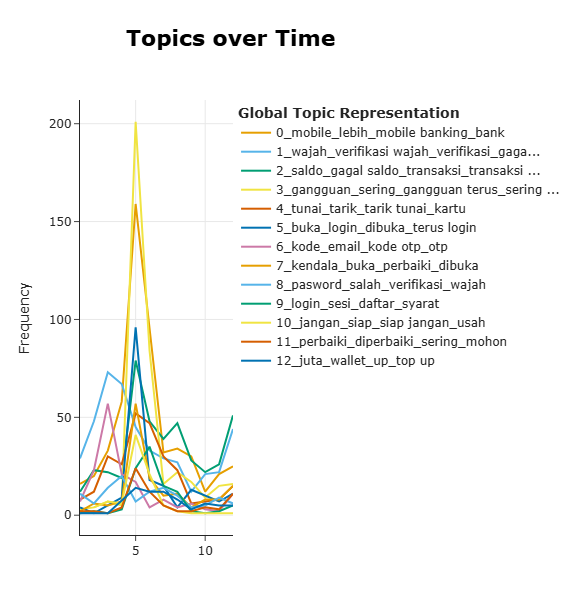

In [33]:
fig_native = topic_model_phase_c.visualize_topics_over_time(
    topics_over_time,
    top_n_topics=13,
    width=1200,
    height=600,
)
fig_native.show()

### 8.6 Setup matplotlib + topic labels

Setup publication-grade rcParams + import labels dari `utils.visualization`. Labels final wondr (13 topics) sudah populated di module.

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Output directory
FIG_DIR = Path("outputs/figures/wondr")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = Path("outputs/tables")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Publication-grade rcParams
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['figure.dpi'] = 100         # display resolution
plt.rcParams['savefig.dpi'] = 300        # publication resolution
plt.rcParams['savefig.bbox'] = 'tight'

# Import labels + plotting functions
from utils.visualization import (
    TOPIC_LABELS_WONDR,
    compute_proportion,
    plot_dtm_smallmultiples,
    plot_dtm_proportion,
    plot_dtm_proportion_highlighted,
)

print(f"FIG_DIR: {FIG_DIR}")
print(f"Number of topic labels: {len(TOPIC_LABELS_WONDR)}")
print(f"Topics in tot_clean: {sorted(tot_clean['Topic'].unique())}")

FIG_DIR: outputs\figures\wondr
Number of topic labels: 13
Topics in tot_clean: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


### 8.7 Generate official plots: small multiples + proportion

- **Small multiples (4×4):** frequency per topic per month, 13 panels + 3 hidden
- **Proportion line plot:** single panel, share of complaints per topic per month — handle base rate effect

Plotting logic encapsulated di `utils/visualization.py` untuk reuse di notebook 06 (BYOND).

In [35]:
# Small multiples (frequency)
sm_path = plot_dtm_smallmultiples(
    tot_clean=tot_clean,
    topic_labels=TOPIC_LABELS_WONDR,
    fig_dir=FIG_DIR,
    app_name="wondr by BNI",
)
print(f"✓ Saved: {sm_path}")

# Proportion plot (single panel, all 13 topics)
prop_path = plot_dtm_proportion(
    tot_clean=tot_clean,
    topic_labels=TOPIC_LABELS_WONDR,
    fig_dir=FIG_DIR,
    app_name="wondr by BNI",
)
print(f"✓ Saved: {prop_path}")

# Compute tot_proportion (for downstream Section 8.8 tables)
tot_proportion = compute_proportion(tot_clean)
print(f"\n✓ tot_proportion ready: {len(tot_proportion)} rows")

# Sanity check: proportion sum per month should ≈ 1.0
print("\nSanity check: proportion sum per month (should all ≈ 1.0)")
print(tot_proportion.groupby('Timestamp')['Proportion'].sum())

✓ Saved: outputs\figures\wondr\08_dtm_smallmultiples.png
✓ Saved: outputs\figures\wondr\08_dtm_proportion.png

✓ tot_proportion ready: 154 rows

Sanity check: proportion sum per month (should all ≈ 1.0)
Timestamp
1     1.0
2     1.0
3     1.0
4     1.0
5     1.0
6     1.0
7     1.0
8     1.0
9     1.0
10    1.0
11    1.0
12    1.0
Name: Proportion, dtype: float64


### 8.8 Generate summary tables

3 CSV reference untuk BAB 4 narrative:

1. **Frequency table** — pivot Topic × Month dengan absolute counts
2. **Proportion table** — pivot Topic × Month dengan normalized proportion
3. **Topic summary** — per-topic peak indicators (Total_N, Peak_Month_Freq, Peak_Month_Prop, dll)

In [36]:
# Table 1: Frequency pivot (Topic × Month)
freq_pivot = tot_clean.pivot_table(
    index='Topic',
    columns='Timestamp',
    values='Frequency',
    fill_value=0,
).astype(int)
freq_pivot.columns = [f"M{int(c)}" for c in freq_pivot.columns]
freq_pivot.insert(0, 'Label', [TOPIC_LABELS_WONDR.get(t, f"Topic {t}") for t in freq_pivot.index])
freq_pivot['Total'] = freq_pivot.iloc[:, 1:].sum(axis=1)

freq_path = TABLE_DIR / "wondr_dtm_freq_table.csv"
freq_pivot.to_csv(freq_path, index_label='Topic')
print(f"✓ Table 1: {freq_path}")

# Table 2: Proportion pivot (Topic × Month)
prop_pivot = tot_proportion.pivot_table(
    index='Topic',
    columns='Timestamp',
    values='Proportion',
    fill_value=0.0,
)
prop_pivot.columns = [f"M{int(c)}" for c in prop_pivot.columns]
prop_pivot.insert(0, 'Label', [TOPIC_LABELS_WONDR.get(t, f"Topic {t}") for t in prop_pivot.index])
prop_pivot['Mean'] = prop_pivot.iloc[:, 1:].mean(axis=1).round(4)

# Round numeric columns
numeric_cols = [c for c in prop_pivot.columns if c != 'Label']
prop_pivot[numeric_cols] = prop_pivot[numeric_cols].round(4)

prop_path = TABLE_DIR / "wondr_dtm_proportion_table.csv"
prop_pivot.to_csv(prop_path, index_label='Topic')
print(f"✓ Table 2: {prop_path}")

# Table 3: Topic summary (per-topic peak indicators)
summary_rows = []
for topic_id in sorted(TOPIC_LABELS_WONDR.keys()):
    topic_freq = tot_clean[tot_clean['Topic'] == topic_id]
    topic_prop = tot_proportion[tot_proportion['Topic'] == topic_id]
    
    if len(topic_freq) == 0:
        continue
    
    peak_freq_row = topic_freq.loc[topic_freq['Frequency'].idxmax()]
    peak_prop_row = topic_prop.loc[topic_prop['Proportion'].idxmax()]
    
    summary_rows.append({
        'Topic': topic_id,
        'Label': TOPIC_LABELS_WONDR[topic_id],
        'Total_N': int(topic_freq['Frequency'].sum()),
        'Peak_Month_Freq': int(peak_freq_row['Timestamp']),
        'Peak_Frequency': int(peak_freq_row['Frequency']),
        'Peak_Month_Prop': int(peak_prop_row['Timestamp']),
        'Peak_Proportion': round(float(peak_prop_row['Proportion']), 4),
        'Mean_Proportion': round(float(topic_prop['Proportion'].mean()), 4),
    })

summary_df = pd.DataFrame(summary_rows)
summary_path = TABLE_DIR / "wondr_topic_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"✓ Table 3: {summary_path}\n")

# Sanity checks
assert summary_df['Total_N'].sum() == 3024, "Total_N mismatch!"
print(f"✓ Total_N sum: {summary_df['Total_N'].sum()} (expected 3024)")

# Proportion sum per month sanity check
prop_sums = prop_pivot.iloc[:, 1:-1].sum(axis=0)  # exclude Label & Mean cols
print(f"✓ Proportion sum per month range: {prop_sums.min():.4f} - {prop_sums.max():.4f} (expected ≈1.0)")
print()
print(summary_df.to_string(index=False))

✓ Table 1: outputs\tables\wondr_dtm_freq_table.csv
✓ Table 2: outputs\tables\wondr_dtm_proportion_table.csv
✓ Table 3: outputs\tables\wondr_topic_summary.csv

✓ Total_N sum: 3024 (expected 3024)
✓ Proportion sum per month range: 0.9997 - 1.0002 (expected ≈1.0)

 Topic                             Label  Total_N  Peak_Month_Freq  Peak_Frequency  Peak_Month_Prop  Peak_Proportion  Mean_Proportion
     0         Mobile Banking comparison      536                5             159                4           0.2367           0.1670
     1            Verifikasi wajah gagal      450                3              73                2           0.3158           0.1854
     2 Saldo terpotong / transaksi gagal      416                5              79               12           0.2361           0.1585
     3            Gangguan & maintenance      399                5             201                5           0.2463           0.0937
     4           Tarik tunai tanpa kartu      264                5  

### 8.9 Highlighted Proportion Plot (Presentation-Ready)

Subset 5 topik narrative untuk highlight, sisanya jadi gray background context. 5 highlighted topics dipilih dengan tiga-act narrative structure:

- **Act 1 (Onboarding pain, M1-M3):** T1 verifikasi wajah, T6 OTP
- **Act 2 (Outage event, M5):** T3 gangguan & maintenance
- **Act 3 (Chronic + emerging):** T0 MB comparison (baseline), T2 saldo terpotong (emerging)

Output: `outputs/figures/wondr/08_dtm_proportion_highlighted.png`

In [37]:
HIGHLIGHT_TOPICS = [0, 1, 2, 3, 6]

highlighted_path = plot_dtm_proportion_highlighted(
    tot_clean=tot_clean,
    topic_labels=TOPIC_LABELS_WONDR,
    fig_dir=FIG_DIR,
    app_name="wondr by BNI",
    highlight_topics=HIGHLIGHT_TOPICS,
)
print(f"✓ Saved: {highlighted_path}")

✓ Saved: outputs\figures\wondr\08_dtm_proportion_highlighted.png


## Section 9 — Cosine Similarity Validation

Validasi konsistensi cluster across 12 bulan dengan dual-approach cosine similarity. Methodological complement untuk DTM Section 8 — answers question: "apakah topic yang sama bener-bener konsisten di bulan-bulan berbeda, atau drift?"

**Two approaches:**

- **D1 (Embedding-level):** cosine sim antar bulan dari **mean centroid IndoBERT** per (topic, bulan). Sensitif ke pergeseran semantic.
- **D2 (c-TF-IDF level):** cosine sim antar bulan dari **binary word-presence vector** (top words BERTopic). Sensitif ke pergeseran lexical.

**Note:** D2 pakai binary word presence (bukan full c-TF-IDF score) — approximation tapi version-independent dari BERTopic internal API. Honest framing: D2 jadi "vocabulary stability proxy".

### 9.0 Setup state untuk Section 9

Section 9 butuh state berbeda dari Section 8:

- `df_clean` (filtered df: rating 1-2 + topic ≠ -1) — bukan `df_wondr`
- `embeddings_clean` (subset embeddings yang align dengan df_clean)
- `tot_raw` (raw topics_over_time, untuk D2 vocab build)

Setup ini jadi entry point kalau lagi resume dari fresh kernel.

In [38]:
import pickle

# Load Phase C model (kalau belum di-load di kernel)
# from bertopic import BERTopic
# topic_model_phase_c = BERTopic.load("data/models/wondr_phase_c", embedding_model=model)

# Load tot_raw dari pickle (kalau belum di kernel)
with open("data/processed/wondr_topics_over_time.pkl", "rb") as f:
    tot_raw = pickle.load(f)

# Assign topic ke df + filter outlier dan rating
df = df_wondr.copy()  # alias biar konsisten dengan handoff naming
df['topic'] = topic_model_phase_c.topics_
df_clean = df[df['topic'] != -1].copy()
df_clean = df_clean[df_clean['rating'].isin([1, 2])].copy()

# Filter embeddings ke index df_clean
embeddings_clean = embeddings_wondr[df_clean.index]

# Sanity checks
assert df_clean.shape[0] == 3024, f"Expected 3024 docs, got {df_clean.shape[0]}"
assert embeddings_clean.shape == (3024, 768), f"Embeddings shape mismatch: {embeddings_clean.shape}"
assert tot_raw[tot_raw['Topic'] != -1]['Topic'].nunique() == 13, "Expected 13 topics"

print(f"✓ df_clean: {df_clean.shape}")
print(f"✓ embeddings_clean: {embeddings_clean.shape}")
print(f"✓ tot_raw: {tot_raw.shape}, topics: {tot_raw[tot_raw['Topic'] != -1]['Topic'].nunique()}")

✓ df_clean: (3024, 7)
✓ embeddings_clean: (3024, 768)
✓ tot_raw: (166, 4), topics: 13


### 9.1 Import cosine_analysis module

Force reload module via importlib — `%autoreload 2` kadang gak pick up function baru di module.

In [39]:
import importlib
import utils.cosine_analysis
importlib.reload(utils.cosine_analysis)

from utils.cosine_analysis import (
    compute_topic_centroids_per_month,
    compute_cosine_sim_matrix_embedding,
    compute_consecutive_sim_embedding,
    build_ctfidf_vectors_per_month,
    compute_cosine_sim_matrix_ctfidf,
    compute_consecutive_sim_ctfidf,
    plot_cosine_heatmaps,
    plot_cosine_lineplot_highlighted,
)

print("✓ cosine_analysis module imported")

✓ cosine_analysis module imported


### 9.2 D1 — Embedding-level cosine similarity

Compute centroid per (topic, month), lalu pairwise cosine sim 12×12 per topic.

In [40]:
df_clean_reset = df_clean.reset_index(drop=True)

# Compute centroids per (topic, month)
centroids_full = compute_topic_centroids_per_month(df_clean_reset, embeddings_clean)
print(f"Topics with centroids: {sorted(centroids_full.keys())}")
print(f"T0 month availability: {[(m, centroids_full[0][m] is not None) for m in range(1, 13)]}")

Topics with centroids: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
T0 month availability: [(1, True), (2, True), (3, True), (4, True), (5, True), (6, True), (7, True), (8, True), (9, True), (10, True), (11, True), (12, True)]


✓ D1 sim matrices computed for 13 topics
Saved: outputs\figures\wondr\09_cosine_embedding_heatmap.png
Saved: outputs\figures\wondr\09_cosine_embedding_lineplot.png


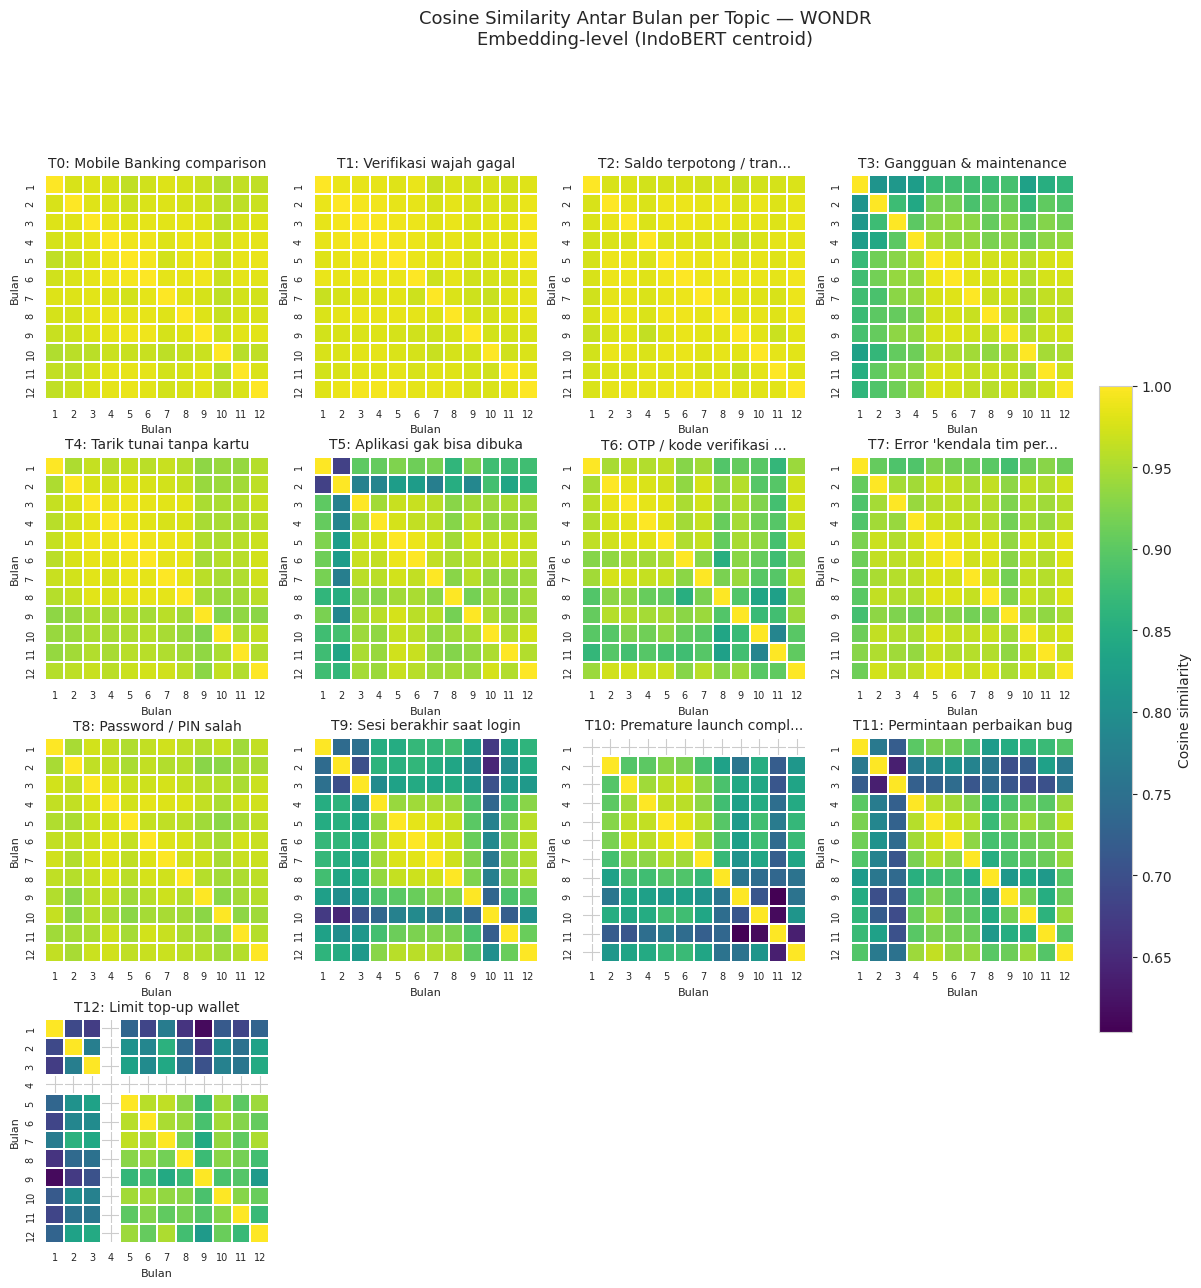

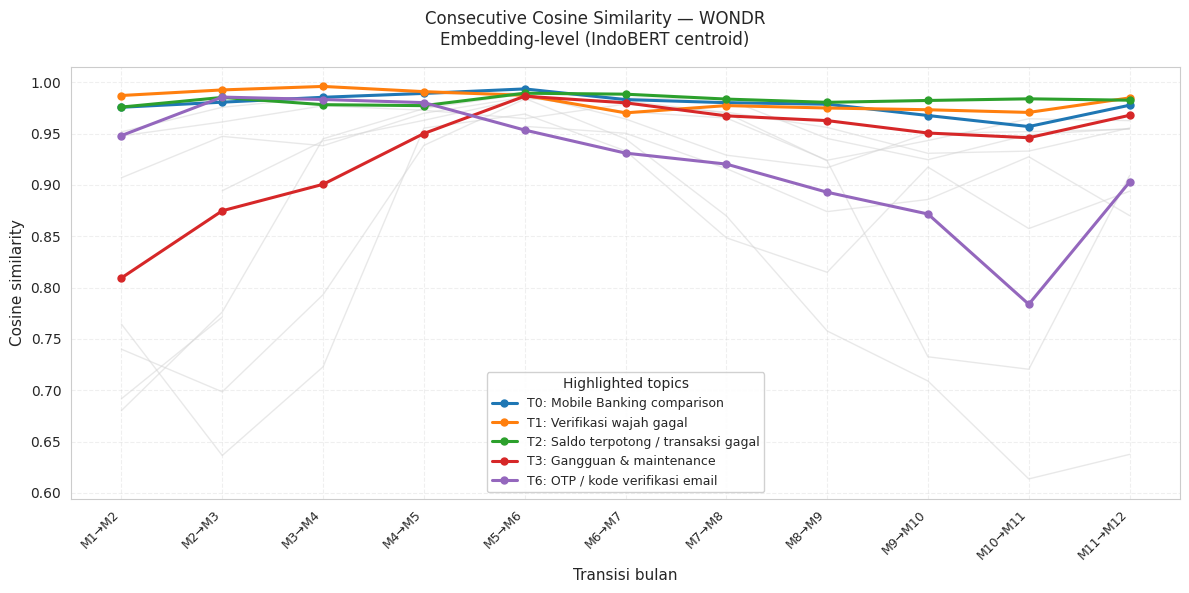

In [41]:
# Compute D1 sim matrices + consecutive sims untuk semua 13 topic
sim_matrices_emb = {}
consecutive_sims_emb = {}
for t in range(13):
    sim_matrices_emb[t] = compute_cosine_sim_matrix_embedding(centroids_full, t)
    consecutive_sims_emb[t] = compute_consecutive_sim_embedding(centroids_full, t)

print(f"✓ D1 sim matrices computed for {len(sim_matrices_emb)} topics")

# Plot D1
fig1 = plot_cosine_heatmaps(
    sim_matrices_emb, TOPIC_LABELS_WONDR, FIG_DIR, "wondr",
    approach="embedding"
)

fig2 = plot_cosine_lineplot_highlighted(
    consecutive_sims_emb, TOPIC_LABELS_WONDR, FIG_DIR, "wondr",
    highlight_topics=[0, 1, 2, 3, 6], approach="embedding"
)

### 9.3 D2 — c-TF-IDF level cosine similarity

Build binary word-presence vectors per (topic, month) dari `Words` column di `tot_raw`.

**Vocab actual size: ~311 kata** — termasuk beberapa n-gram ("becus kerjanya", "berjam jam") consequence dari `CountVectorizer` setting `ngram_range=(1, 2)` di BERTopic. Bukan bug.

In [42]:
# Build vocab + vectors dari tot_raw
vectors, vocab = build_ctfidf_vectors_per_month(tot_raw)
print(f"Vocab size: {len(vocab)}")
print(f"Sample vocab[:20]: {vocab[:20]}")

Vocab size: 311
Sample vocab[:20]: ['aksesibilitas', 'akun', 'aneh mana', 'apaan', 'arab', 'awal', 'awalnya', 'bagaimana pas', 'bagus', 'bank', 'barusan', 'becus kerjanya', 'benahi', 'bener siap', 'berakhir', 'berjam', 'berjam jam', 'berkurang', 'bermutu', 'bersihkan']


✓ D2 sim matrices computed for 13 topics
Saved: outputs\figures\wondr\09_cosine_ctfidf_heatmap.png
Saved: outputs\figures\wondr\09_cosine_ctfidf_lineplot.png


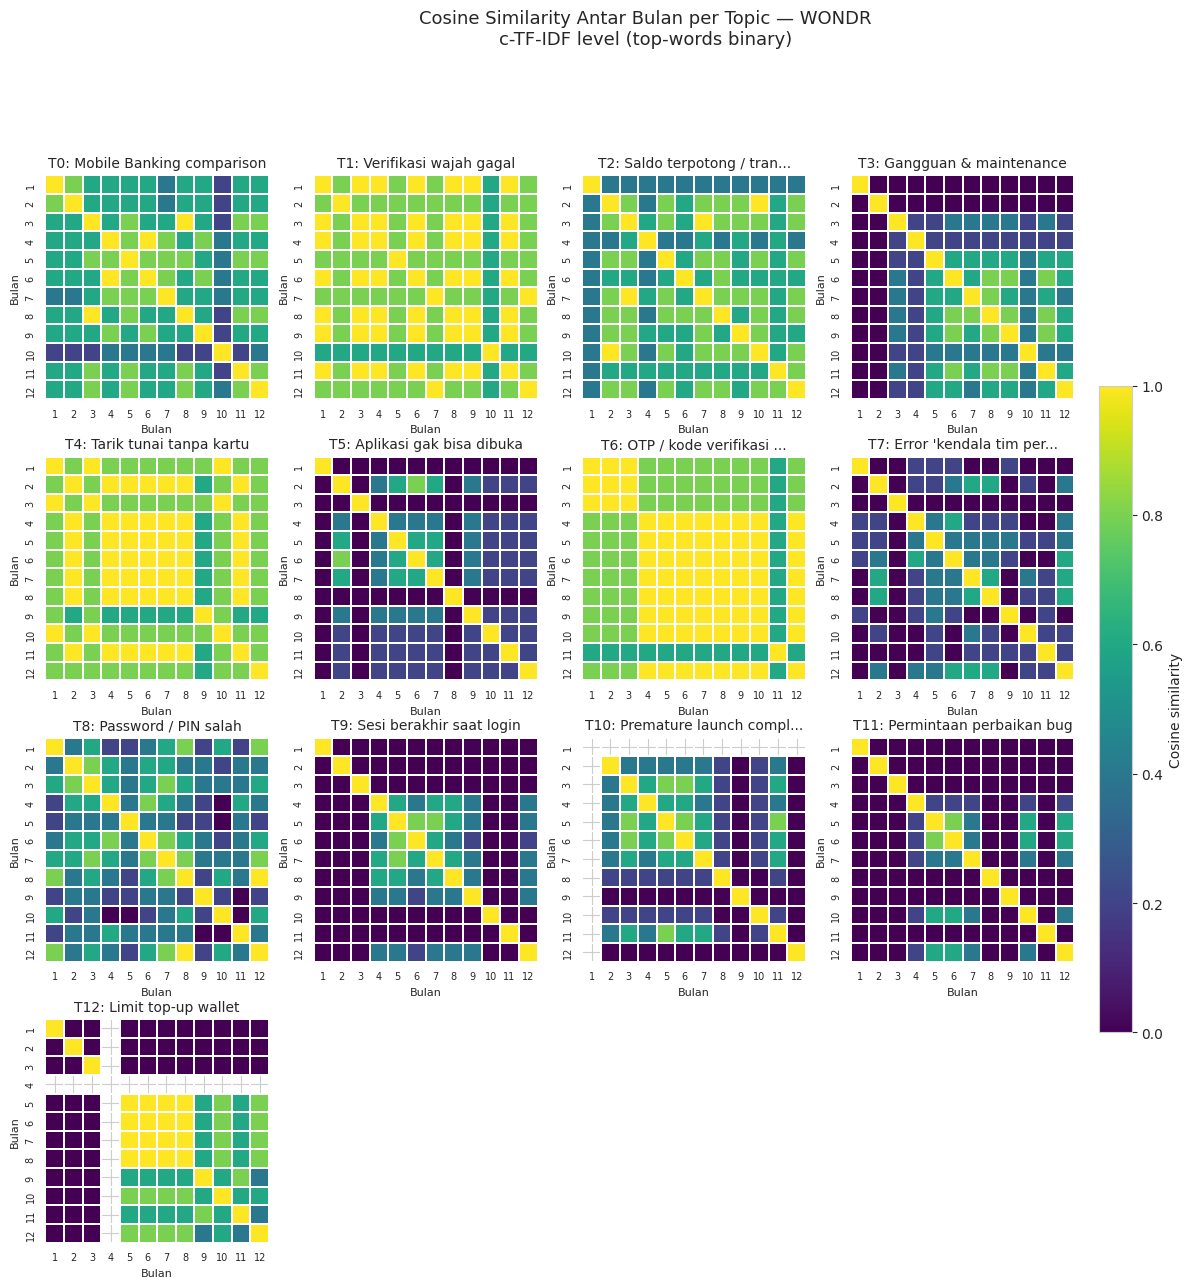

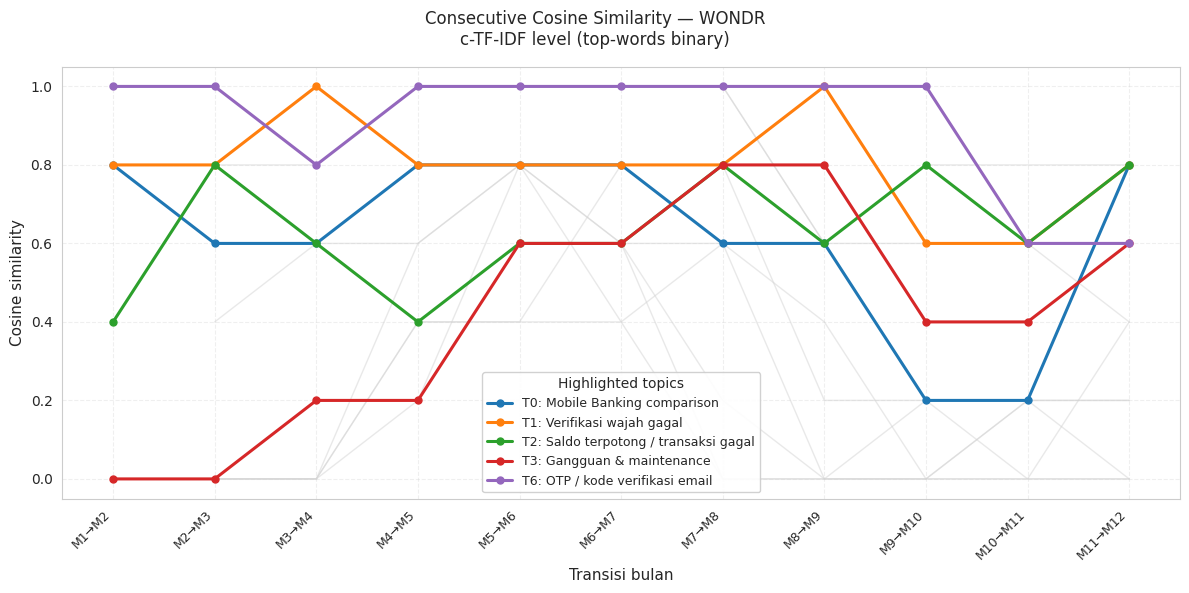

In [43]:
# Compute D2 sim matrices + consecutive sims
sim_matrices_ctf = {}
consecutive_sims_ctf = {}
for t in range(13):
    sim_matrices_ctf[t] = compute_cosine_sim_matrix_ctfidf(vectors, t)
    consecutive_sims_ctf[t] = compute_consecutive_sim_ctfidf(vectors, t)

print(f"✓ D2 sim matrices computed for {len(sim_matrices_ctf)} topics")

# Plot D2 (approach="ctfidf" biar filename + title bener)
fig3 = plot_cosine_heatmaps(
    sim_matrices_ctf, TOPIC_LABELS_WONDR, FIG_DIR, "wondr",
    approach="ctfidf"
)

fig4 = plot_cosine_lineplot_highlighted(
    consecutive_sims_ctf, TOPIC_LABELS_WONDR, FIG_DIR, "wondr",
    highlight_topics=[0, 1, 2, 3, 6], approach="ctfidf"
)

### 9.4 D3 — Comparison & categorization

Compute mean off-diagonal sim per topic untuk D1 + D2, kategorisasi pattern, identify outlier months.

**Threshold initial:** D1 ≥ 0.95, D2 ≥ 0.60. **Catatan:** threshold ini ke-fit empiris tapi belum di-justify formal — sensitivity check di Section 9.5 akan revisi threshold ke D1 ≥ 0.90.

In [44]:
def mean_off_diagonal(sim_matrix):
    """Mean cosine sim off-diagonal, abaikan NaN."""
    M = sim_matrix.values.copy()
    np.fill_diagonal(M, np.nan)
    return np.nanmean(M)

THRESHOLD_D1 = 0.95
THRESHOLD_D2 = 0.60

def categorize(d1, d2):
    d1_high = d1 >= THRESHOLD_D1
    d2_high = d2 >= THRESHOLD_D2
    if d1_high and d2_high:
        return 'Stable'
    elif d1_high and not d2_high:
        return 'Paraphrase'
    elif not d1_high and d2_high:
        return 'Lexical-anchor drift'
    else:
        return 'Topic drift'

def find_outlier_months(sim_matrix, threshold_drop=0.05):
    """
    Cari bulan yang sim mean-nya (ke bulan lain) jauh di bawah overall mean.
    Return list of (month, mean_sim).
    """
    M = sim_matrix.values.copy()
    np.fill_diagonal(M, np.nan)
    overall_mean = np.nanmean(M)
    per_month_mean = np.nanmean(M, axis=1)
    
    outliers = []
    for i, m_mean in enumerate(per_month_mean):
        if not np.isnan(m_mean) and m_mean < overall_mean - threshold_drop:
            month = sim_matrix.index[i]
            outliers.append((int(month), round(float(m_mean), 4)))
    return outliers

# Build comparison DataFrame
records = []
for t in range(13):
    d1_mean = mean_off_diagonal(sim_matrices_emb[t])
    d2_mean = mean_off_diagonal(sim_matrices_ctf[t])
    records.append({
        'Topic': t,
        'Label': TOPIC_LABELS_WONDR.get(t, f'T{t}'),
        'D1_mean': round(d1_mean, 4),
        'D2_mean': round(d2_mean, 4),
        'Pattern': categorize(d1_mean, d2_mean),
        'D1_outlier_months': find_outlier_months(sim_matrices_emb[t]),
        'D2_outlier_months': find_outlier_months(sim_matrices_ctf[t], threshold_drop=0.15),
    })

df_compare = pd.DataFrame(records)

# Save
csv_path = TABLE_DIR / 'wondr_section9_comparison.csv'
df_compare.to_csv(csv_path, index=False)
print(f"✓ Saved: {csv_path}")

# Display
print("\n=== Section 9 Comparison: D1 vs D2 (wondr) ===\n")
print(df_compare[['Topic', 'Label', 'D1_mean', 'D2_mean', 'Pattern']].to_string(index=False))

print("\n=== Pattern distribution (initial threshold) ===")
print(df_compare['Pattern'].value_counts())

✓ Saved: outputs\tables\wondr_section9_comparison.csv

=== Section 9 Comparison: D1 vs D2 (wondr) ===

 Topic                             Label  D1_mean  D2_mean              Pattern
     0         Mobile Banking comparison   0.9758   0.6061               Stable
     1            Verifikasi wajah gagal   0.9811   0.8333               Stable
     2 Saldo terpotong / transaksi gagal   0.9817   0.6364               Stable
     3            Gangguan & maintenance   0.9251   0.3182          Topic drift
     4           Tarik tunai tanpa kartu   0.9612   0.8485               Stable
     5          Aplikasi gak bisa dibuka   0.9195   0.1758          Topic drift
     6       OTP / kode verifikasi email   0.9263   0.8606 Lexical-anchor drift
     7      Error 'kendala tim perbaiki'   0.9482   0.1970          Topic drift
     8              Password / PIN salah   0.9589   0.4424           Paraphrase
     9          Sesi berakhir saat login   0.8575   0.1515          Topic drift
    10        Pre

C:\Users\Rabithah Zahiratus S\AppData\Local\Temp\ipykernel_6968\4103203935.py:30: RuntimeWarning: Mean of empty slice
  per_month_mean = np.nanmean(M, axis=1)


## Section 9.5 — Threshold Sensitivity Check

Threshold initial (D1=0.95, D2=0.60) ke-fit empiris tapi belum di-justify formal. Section 9.5 plot histogram D1 + D2, identify natural gap, justify threshold final.

**Finding utama:** Histogram D1 menunjukkan **bimodal distribution dengan natural gap di 0.86-0.92** (bin kosong 0.87-0.91). Threshold lama 0.95 memotong tengah cluster high → terlalu agresif.

**Threshold final wondr:**
- **D1 ≥ 0.90** (revised dari 0.95) — aligned dengan natural breakpoint
- **D2 ≥ 0.60** (retained) — natural gap di 0.45-0.55

⚠️ **Untuk BYOND:** distribusi natural gap mungkin beda. Lakukan threshold sensitivity check terpisah untuk BYOND, **jangan asumsi threshold sama**.

### 9.5.1 Plot histogram distribusi D1 + D2

In [45]:
# Load Section 9 comparison results
df_section9 = pd.read_csv(TABLE_DIR / "wondr_section9_comparison.csv")
print(f"Shape: {df_section9.shape}")
print(f"D1 range: {df_section9['D1_mean'].min():.4f} - {df_section9['D1_mean'].max():.4f}")
print(f"D2 range: {df_section9['D2_mean'].min():.4f} - {df_section9['D2_mean'].max():.4f}")

Shape: (13, 7)
D1 range: 0.8323 - 0.9817
D2 range: 0.0939 - 0.8606


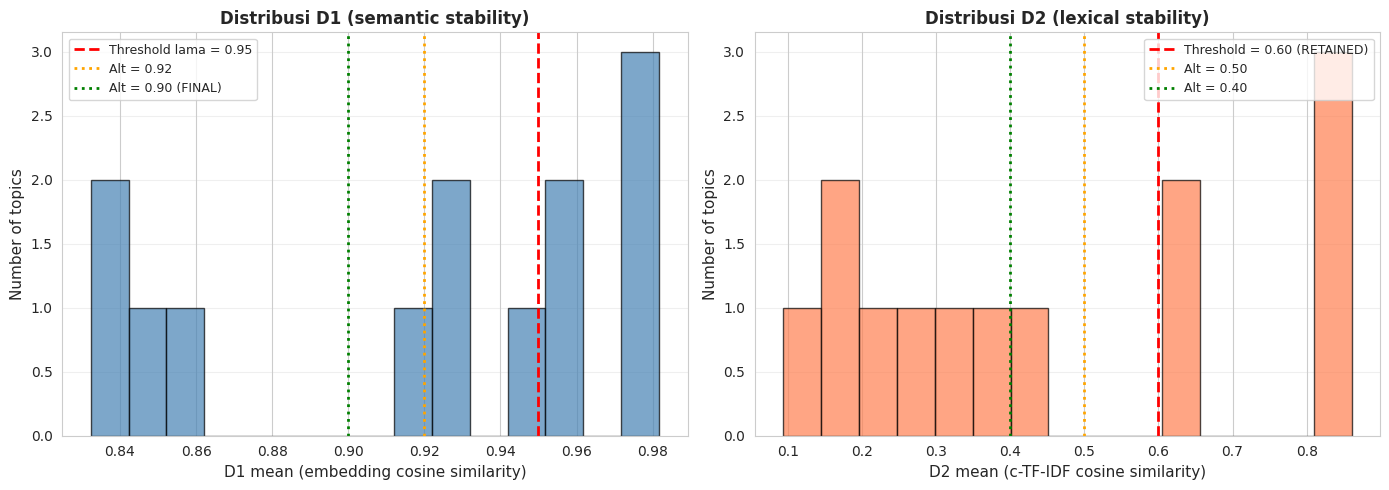

✓ Saved: outputs\figures\wondr\09_threshold_sensitivity_histogram.png


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# D1 histogram (embedding-level, semantic)
axes[0].hist(df_section9['D1_mean'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(0.95, color='red', linestyle='--', linewidth=2, label='Threshold lama = 0.95')
axes[0].axvline(0.92, color='orange', linestyle=':', linewidth=2, label='Alt = 0.92')
axes[0].axvline(0.90, color='green', linestyle=':', linewidth=2, label='Alt = 0.90 (FINAL)')
axes[0].set_xlabel('D1 mean (embedding cosine similarity)', fontsize=11)
axes[0].set_ylabel('Number of topics', fontsize=11)
axes[0].set_title('Distribusi D1 (semantic stability)', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# D2 histogram (c-TF-IDF level, lexical)
axes[1].hist(df_section9['D2_mean'], bins=15, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(0.60, color='red', linestyle='--', linewidth=2, label='Threshold = 0.60 (RETAINED)')
axes[1].axvline(0.50, color='orange', linestyle=':', linewidth=2, label='Alt = 0.50')
axes[1].axvline(0.40, color='green', linestyle=':', linewidth=2, label='Alt = 0.40')
axes[1].set_xlabel('D2 mean (c-TF-IDF cosine similarity)', fontsize=11)
axes[1].set_ylabel('Number of topics', fontsize=11)
axes[1].set_title('Distribusi D2 (lexical stability)', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()

hist_path = FIG_DIR / "09_threshold_sensitivity_histogram.png"
plt.savefig(hist_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {hist_path}")

### 9.5.2 Reklasifikasi dengan threshold final

5 dari 13 topic berubah klasifikasi dengan threshold baru (D1=0.90):

- **T3, T5, T7** Topic drift → **Paraphrase** (semantic ternyata stable, hanya lexical drift)
- **T6** Lexical-anchor drift → **Stable** (semantic + lexical keduanya stabil)
- **T8** Paraphrase (no change, retained)

In [47]:
# Reklasifikasi dengan threshold yang aligned ke natural gap
D1_THRESHOLD_NEW = 0.90
D2_THRESHOLD_NEW = 0.60

def classify_pattern(d1, d2, d1_th, d2_th):
    if d1 >= d1_th and d2 >= d2_th:
        return "Stable"
    elif d1 >= d1_th and d2 < d2_th:
        return "Paraphrase"
    elif d1 < d1_th and d2 >= d2_th:
        return "Lexical-anchor drift"
    else:
        return "Topic drift"

# Apply both old (0.95/0.60) and new (0.90/0.60) classification
df_section9['Pattern_old'] = df_section9['Pattern']
df_section9['Pattern_new'] = df_section9.apply(
    lambda row: classify_pattern(row['D1_mean'], row['D2_mean'], D1_THRESHOLD_NEW, D2_THRESHOLD_NEW),
    axis=1
)

# Compare side-by-side
comparison = df_section9[['Topic', 'Label', 'D1_mean', 'D2_mean', 'Pattern_old', 'Pattern_new']].copy()
comparison['Changed'] = comparison['Pattern_old'] != comparison['Pattern_new']

print(f"Topics yang reklasifikasi: {comparison['Changed'].sum()} dari {len(comparison)}")
print(f"\nDistribusi Pattern_old (threshold 0.95):")
print(comparison['Pattern_old'].value_counts())
print(f"\nDistribusi Pattern_new (threshold 0.90):")
print(comparison['Pattern_new'].value_counts())
print(f"\nDetail reklasifikasi:")
print(comparison.to_string(index=False))

Topics yang reklasifikasi: 4 dari 13

Distribusi Pattern_old (threshold 0.95):
Pattern_old
Topic drift             7
Stable                  4
Lexical-anchor drift    1
Paraphrase              1
Name: count, dtype: int64

Distribusi Pattern_new (threshold 0.90):
Pattern_new
Stable         5
Paraphrase     4
Topic drift    4
Name: count, dtype: int64

Detail reklasifikasi:
 Topic                             Label  D1_mean  D2_mean          Pattern_old Pattern_new  Changed
     0         Mobile Banking comparison   0.9758   0.6061               Stable      Stable    False
     1            Verifikasi wajah gagal   0.9811   0.8333               Stable      Stable    False
     2 Saldo terpotong / transaksi gagal   0.9817   0.6364               Stable      Stable    False
     3            Gangguan & maintenance   0.9251   0.3182          Topic drift  Paraphrase     True
     4           Tarik tunai tanpa kartu   0.9612   0.8485               Stable      Stable    False
     5          Apl

### 9.5.3 Finalize: replace Pattern + backup CSV lama

Pattern column di `wondr_section9_comparison.csv` di-overwrite dengan threshold baru. Versi lama di-backup ke `wondr_section9_comparison_threshold_old.csv` untuk audit trail.

In [48]:
import shutil

# Finalize: replace Pattern dengan klasifikasi baru, keep old as backup column
df_section9_final = df_section9.copy()
df_section9_final['Pattern'] = df_section9_final['Pattern_new']
df_section9_final['Pattern_threshold_old'] = df_section9_final['Pattern_old']

# Drop intermediate columns
df_section9_final = df_section9_final.drop(columns=['Pattern_old', 'Pattern_new'])

# Reorder columns
cols_order = ['Topic', 'Label', 'D1_mean', 'D2_mean', 'Pattern', 
              'Pattern_threshold_old', 'D1_outlier_months', 'D2_outlier_months']
df_section9_final = df_section9_final[cols_order]

# Backup old version
shutil.copy(
    TABLE_DIR / "wondr_section9_comparison.csv",
    TABLE_DIR / "wondr_section9_comparison_threshold_old.csv"
)

# Overwrite with updated
df_section9_final.to_csv(TABLE_DIR / "wondr_section9_comparison.csv", index=False)
print("✓ Saved: outputs/tables/wondr_section9_comparison.csv (threshold updated)")
print("✓ Backup: outputs/tables/wondr_section9_comparison_threshold_old.csv")
print(f"\nFinal classification (threshold 0.90):")
print(df_section9_final['Pattern'].value_counts())

✓ Saved: outputs/tables/wondr_section9_comparison.csv (threshold updated)
✓ Backup: outputs/tables/wondr_section9_comparison_threshold_old.csv

Final classification (threshold 0.90):
Pattern
Stable         5
Paraphrase     4
Topic drift    4
Name: count, dtype: int64


## Section 10 — Mann-Kendall Trend Test

Uji statistik untuk validasi tren temporal pada prevalensi topik mingguan.

**Setup:**
- **Granularity:** mingguan (52 datapoint, 7-day blocks dari launch date 5 Juli 2024)
- **Test:** Hamed-Rao modified Mann-Kendall (handle autokorelasi temporal, Hamed & Rao 1998)
- **Magnitude estimator:** Sen's slope (Sen 1968)
- **α:** 0.05
- **Multiple testing correction:** FDR Benjamini-Hochberg (q=0.05)

**Series yang diuji (cross-validation):**
- **Proportion** per topic per minggu (share of complaints)
- **Frequency** per topic per minggu (count absolut)

⚠️ **Note untuk BAB 3:** FDR-BH **diputuskan empiris di sesi v9, BUKAN tertulis di proposal**. Perlu append paragraf metodologi:
> Dengan menerapkan uji Mann-Kendall pada 13 topik secara bersamaan untuk masing-masing seri (proporsi dan frekuensi), terdapat risiko inflasi family-wise error rate akibat multiple testing. Untuk mengontrol proporsi false discovery di antara klaim signifikan, prosedur koreksi Benjamini-Hochberg (Benjamini & Hochberg, 1995) diterapkan pada p-value mentah dengan false discovery rate (q) = 0,05.

**Note dual granularity:** Wondr pakai bulanan untuk Section 8-9 dan mingguan untuk Section 10 — **bukan inconsistency, by design** sesuai BAB 3.

### 10.1 Import trend_analysis module

In [49]:
import importlib
import utils.trend_analysis
importlib.reload(utils.trend_analysis)

from utils.trend_analysis import (
    compute_weekly_series_from_relative_week,
    apply_mann_kendall_per_topic,
    apply_fdr_correction,
    plot_trend_summary,
    plot_significant_trends_lines,
)

# Sanity check kolom
print("Columns df_clean:", df_clean.columns.tolist())
print(f"Range relative_week: {df_clean['relative_week'].min()} - {df_clean['relative_week'].max()}")
print(f"Total docs: {df_clean.shape[0]}")

Columns df_clean: ['review_id', 'review_text_cleaned', 'relative_month', 'relative_week', 'date_wib', 'rating', 'topic']
Range relative_week: 1 - 52
Total docs: 3024


### 10.2 Aggregate ke weekly series

Pakai kolom `relative_week` yang udah precomputed di preprocessing — konsisten dengan validasi Phase 1-4.

In [50]:
weekly_series = compute_weekly_series_from_relative_week(
    df_clean=df_clean,
    n_weeks=52,
)

print(f"Shape frequency: {weekly_series['frequency'].shape}")
print(f"Shape proportion: {weekly_series['proportion'].shape}")
print(f"Weekly totals (range): {weekly_series['weekly_totals'].min()} - {weekly_series['weekly_totals'].max()}")
print(f"Total complaints across 52 weeks: {weekly_series['weekly_totals'].sum()}")

assert weekly_series['weekly_totals'].sum() == 3024, "Total mismatch!"
print(f"\nFrequency head:")
print(weekly_series['frequency'].head())

Shape frequency: (52, 13)
Shape proportion: (52, 13)
Weekly totals (range): 13 - 508
Total complaints across 52 weeks: 3024

Frequency head:
topic          0   1   2   3   4   5   6   7   8   9   10  11  12
relative_week                                                    
1               5   8   3   0   3   0   4   0   1   0   0   1   1
2               0   3   2   1   0   2   1   2   4   1   0   1   0
3               3   5   0   0   2   0   1   0   2   0   0   0   0
4               6  12   4   2   1   2   1   0   2   0   0   0   0
5               3   1   7   0   3   1   1   0   2   0   0   0   0


### 10.3 Mann-Kendall test pada series proportion

In [51]:
mk_results_prop = apply_mann_kendall_per_topic(
    series_df=weekly_series['proportion'],
    topic_labels=TOPIC_LABELS_WONDR,
    series_type='proportion',
    alpha=0.05,
)

# Apply FDR-BH correction
mk_results_prop = apply_fdr_correction(mk_results_prop, alpha=0.05)

# Display sorted by adjusted p-value
mk_results_prop_sorted = mk_results_prop.sort_values('MK_p_value_adj').reset_index(drop=True)
mk_results_prop_sorted

,Topic,Label,Series_Type,MK_trend,MK_p_value,MK_z,Sen_slope,Sen_intercept,Tau,Significant,Classification,MK_p_value_adj,Significant_FDR,Classification_FDR
0,3,Gangguan & maintenance,proportion,increasing,0.000261,3.650948,0.001923,0.009214,0.349170,True,emerging,0.001445,True,emerging
1,2,Saldo terpotong / transaksi gagal,proportion,increasing,0.000445,3.512039,0.002794,0.073703,0.336350,True,emerging,0.001445,True,emerging
2,7,Error 'kendala tim perbaiki',proportion,increasing,0.000336,3.585615,0.001107,0.016884,0.342383,True,emerging,0.001445,True,emerging
3,12,Limit top-up wallet,proportion,increasing,0.000253,3.658901,0.000580,0.001009,0.285822,True,emerging,0.001445,True,emerging
4,5,Aplikasi gak bisa dibuka,proportion,increasing,0.010978,2.543404,0.000840,0.018290,0.242836,True,emerging,0.028542,True,emerging
5,4,Tarik tunai tanpa kartu,proportion,decreasing,0.032431,-2.139059,-0.001055,0.117501,-0.205128,True,declining,0.055107,False,stable
6,11,Permintaan perbaikan bug,proportion,increasing,0.027830,2.199673,0.000016,0.014874,0.175716,True,emerging,0.055107,False,stable
7,6,OTP / kode verifikasi email,proportion,decreasing,0.033912,-2.121117,-0.001025,0.064829,-0.254148,True,declining,0.055107,False,stable
8,8,Password / PIN salah,proportion,no trend,0.247000,-1.157666,-0.000317,0.054834,-0.083710,False,stable,0.342236,False,stable
9,1,Verifikasi wajah gagal,proportion,no trend,0.263258,-1.118724,-0.002509,0.234819,-0.184766,False,stable,0.342236,False,stable


### 10.4 Mann-Kendall test pada series frequency

In [52]:
mk_results_freq = apply_mann_kendall_per_topic(
    series_df=weekly_series['frequency'],
    topic_labels=TOPIC_LABELS_WONDR,
    series_type='frequency',
    alpha=0.05,
)

mk_results_freq = apply_fdr_correction(mk_results_freq, alpha=0.05)

mk_results_freq_sorted = mk_results_freq.sort_values('MK_p_value_adj').reset_index(drop=True)
mk_results_freq_sorted

,Topic,Label,Series_Type,MK_trend,MK_p_value,MK_z,Sen_slope,Sen_intercept,Tau,Significant,Classification,MK_p_value_adj,Significant_FDR,Classification_FDR
0,11,Permintaan perbaikan bug,frequency,increasing,0.000025,4.212673,0.000000,1.000000,0.131222,True,declining,0.000328,True,declining
1,3,Gangguan & maintenance,frequency,increasing,0.019560,2.334679,0.054054,1.621622,0.259427,True,emerging,0.084761,False,stable
2,2,Saldo terpotong / transaksi gagal,frequency,increasing,0.019530,2.335263,0.068966,4.741379,0.205128,True,emerging,0.084761,False,stable
3,7,Error 'kendala tim perbaiki',frequency,increasing,0.049126,1.967499,0.028571,1.271429,0.215686,True,emerging,0.142986,False,stable
4,5,Aplikasi gak bisa dibuka,frequency,no trend,0.054995,1.918918,0.022992,1.413716,0.180241,False,stable,0.142986,False,stable
5,6,OTP / kode verifikasi email,frequency,no trend,0.084060,-1.727599,-0.021981,1.560507,-0.204374,False,stable,0.171332,False,stable
6,8,Password / PIN salah,frequency,no trend,0.105435,-1.619055,0.000000,2.000000,-0.143288,False,stable,0.171332,False,stable
7,1,Verifikasi wajah gagal,frequency,no trend,0.104916,-1.621472,-0.109903,9.802536,-0.241327,False,stable,0.171332,False,stable
8,12,Limit top-up wallet,frequency,no trend,0.185207,1.324893,0.000000,1.000000,0.199849,False,stable,0.267521,False,stable
9,10,Premature launch complaint,frequency,no trend,0.343619,-0.947039,0.000000,0.500000,-0.151584,False,stable,0.446705,False,stable


### 10.5 Comparison: proportion vs frequency

Cross-validation antara dua series:

- **Robust trends** (significant di kedua series) — paling kuat, bukan artifak volume
- **Proportion-only significant** — relative trend, bukan absolute. Hati-hati interpretasi.
- **Frequency-only significant** — kemungkinan artifak volume keseluruhan

In [53]:
comparison = pd.DataFrame({
    'Topic': mk_results_prop['Topic'],
    'Label': mk_results_prop['Label'],
    'Class_Proportion': mk_results_prop['Classification_FDR'],
    'Class_Frequency': mk_results_freq['Classification_FDR'],
    'Slope_Proportion': mk_results_prop['Sen_slope'].round(5),
    'Slope_Frequency': mk_results_freq['Sen_slope'].round(3),
    'p_adj_Proportion': mk_results_prop['MK_p_value_adj'].round(4),
    'p_adj_Frequency': mk_results_freq['MK_p_value_adj'].round(4),
})

comparison['Consistent'] = comparison['Class_Proportion'] == comparison['Class_Frequency']

print(f"Topic dengan klasifikasi konsisten (FDR-BH): {comparison['Consistent'].sum()}/13")
print(f"\n{comparison.to_string(index=False)}")

Topic dengan klasifikasi konsisten (FDR-BH): 7/13

 Topic                             Label Class_Proportion Class_Frequency  Slope_Proportion  Slope_Frequency  p_adj_Proportion  p_adj_Frequency  Consistent
     0         Mobile Banking comparison           stable          stable          -0.00055           -0.048            0.4315           0.6808        True
     1            Verifikasi wajah gagal           stable          stable          -0.00251           -0.110            0.3422           0.1713        True
     2 Saldo terpotong / transaksi gagal         emerging          stable           0.00279            0.069            0.0014           0.0848       False
     3            Gangguan & maintenance         emerging          stable           0.00192            0.054            0.0014           0.0848       False
     4           Tarik tunai tanpa kartu           stable          stable          -0.00105           -0.028            0.0551           0.6158        True
     5       

### 10.6 Save tabel hasil

In [54]:
mk_results_prop.to_csv(TABLE_DIR / 'wondr_mk_proportion.csv', index=False)
mk_results_freq.to_csv(TABLE_DIR / 'wondr_mk_frequency.csv', index=False)
comparison.to_csv(TABLE_DIR / 'wondr_mk_comparison.csv', index=False)

print("✓ Saved 3 tables:")
print("  - wondr_mk_proportion.csv")
print("  - wondr_mk_frequency.csv")
print("  - wondr_mk_comparison.csv")

✓ Saved 3 tables:
  - wondr_mk_proportion.csv
  - wondr_mk_frequency.csv
  - wondr_mk_comparison.csv


### 10.7 Forest plots: Sen's slope summary

Forest plot per series — Sen's slope (effect size), filled marker = significant FDR-corrected, color hijau=emerging / merah=declining / abu=stable.

✓ Saved: outputs\figures\wondr\10_mk_forest_proportion.png


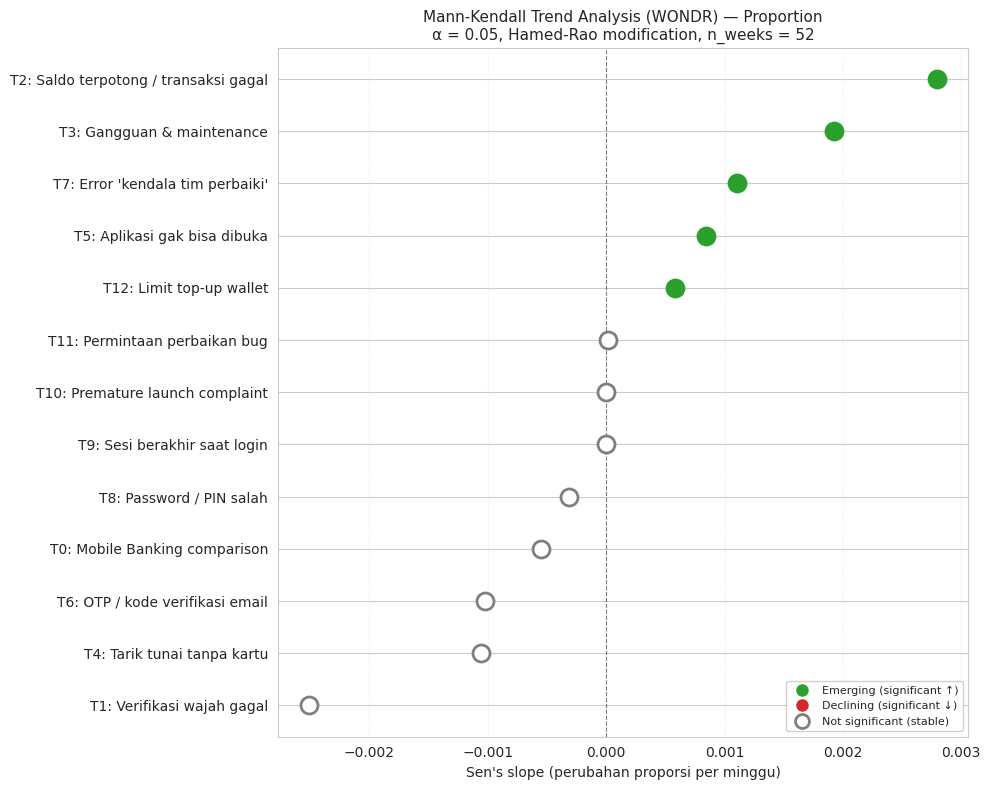

In [65]:
# Forest plot: proportion (FDR-corrected)
mk_results_prop_for_plot = mk_results_prop.copy()
mk_results_prop_for_plot['Classification'] = mk_results_prop['Classification_FDR']
mk_results_prop_for_plot['Significant'] = mk_results_prop['Significant_FDR']

fig_prop = plot_trend_summary(
    mk_results=mk_results_prop_for_plot,
    fig_dir=FIG_DIR,
    app_name='wondr',
    series_type='proportion',
    alpha=0.05,
)
plt.show()

✓ Saved: outputs\figures\wondr\10_mk_forest_frequency.png


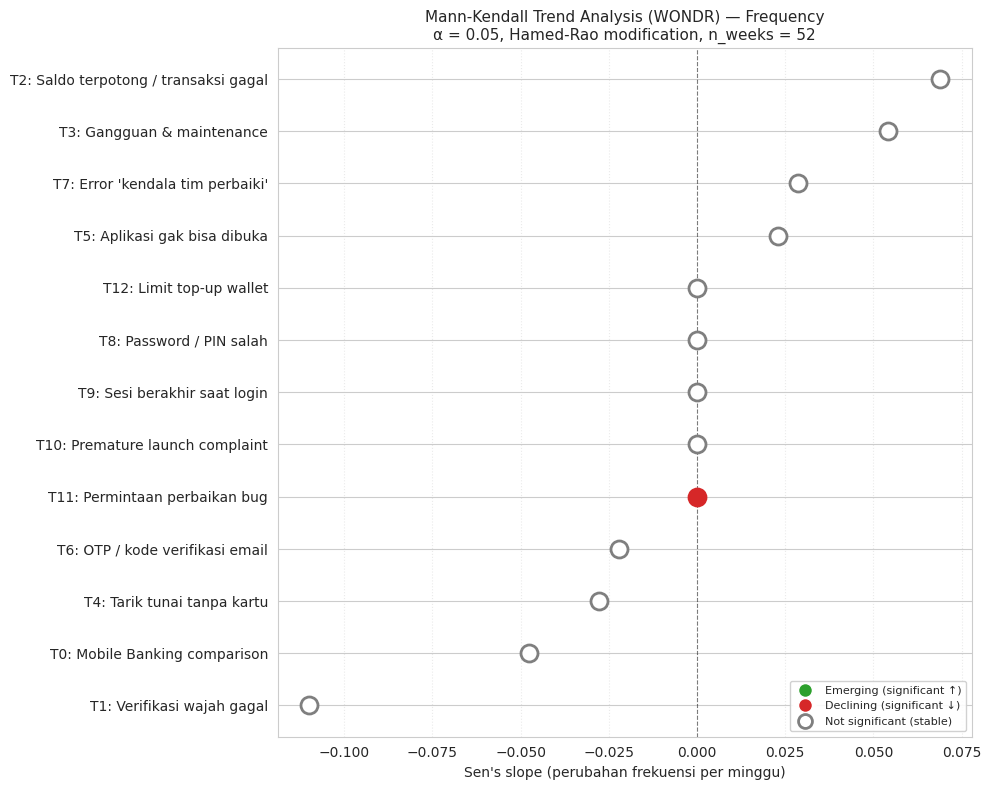

In [56]:
# Forest plot: frequency (FDR-corrected)
mk_results_freq_for_plot = mk_results_freq.copy()
mk_results_freq_for_plot['Classification'] = mk_results_freq['Classification_FDR']
mk_results_freq_for_plot['Significant'] = mk_results_freq['Significant_FDR']

fig_freq = plot_trend_summary(
    mk_results=mk_results_freq_for_plot,
    fig_dir=FIG_DIR,
    app_name='wondr',
    series_type='frequency',
    alpha=0.05,
)
plt.show()

### 10.8 Significant trend lines

Small multiples lineplot khusus topic significant — overlay Sen's slope dashed line untuk visualize magnitude.

✓ Saved: outputs\figures\wondr\10_mk_significant_lines_proportion.png


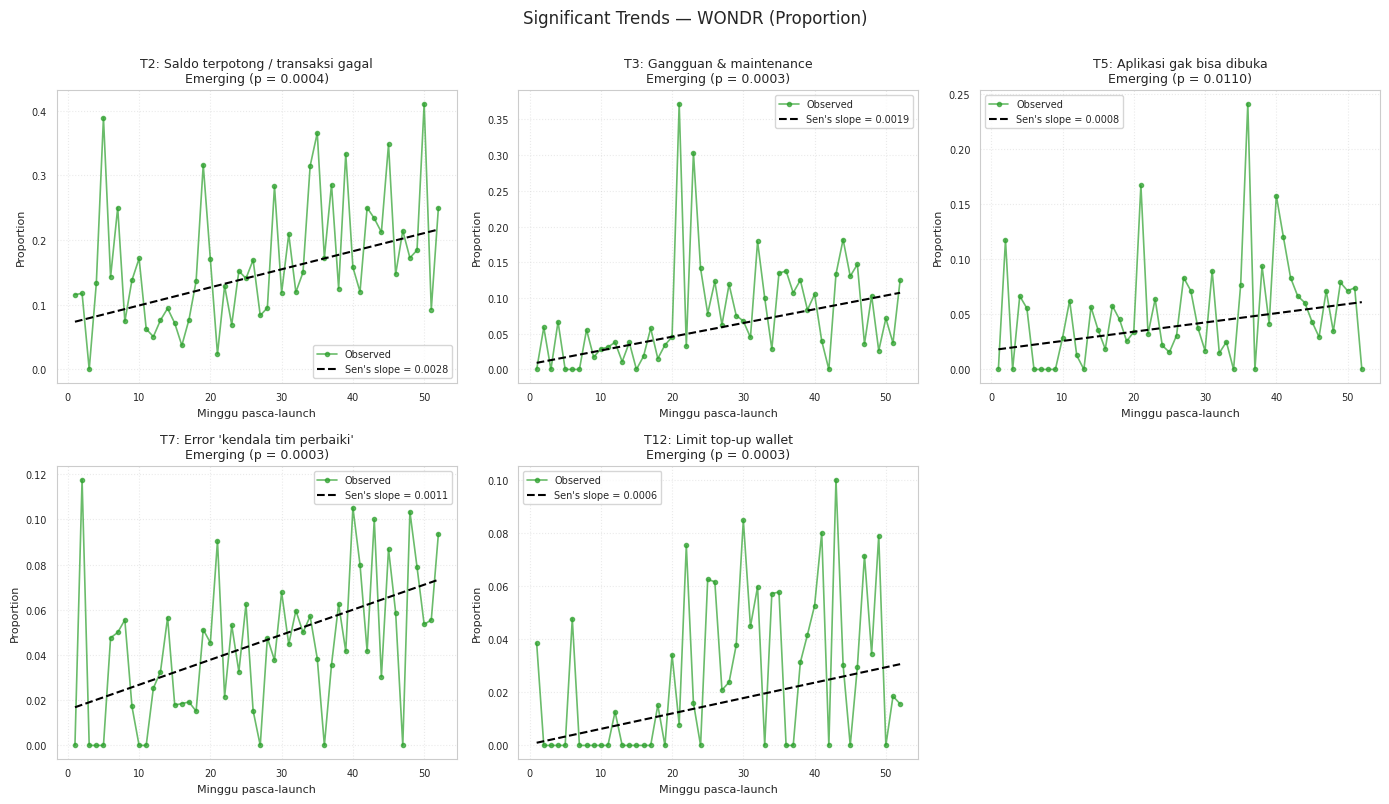

In [57]:
# Lineplot: proportion (significant only)
fig_sig_prop = plot_significant_trends_lines(
    series_df=weekly_series['proportion'],
    mk_results=mk_results_prop_for_plot,
    topic_labels=TOPIC_LABELS_WONDR,
    fig_dir=FIG_DIR,
    app_name='wondr',
    series_type='proportion',
)
plt.show()

✓ Saved: outputs\figures\wondr\10_mk_significant_lines_frequency.png


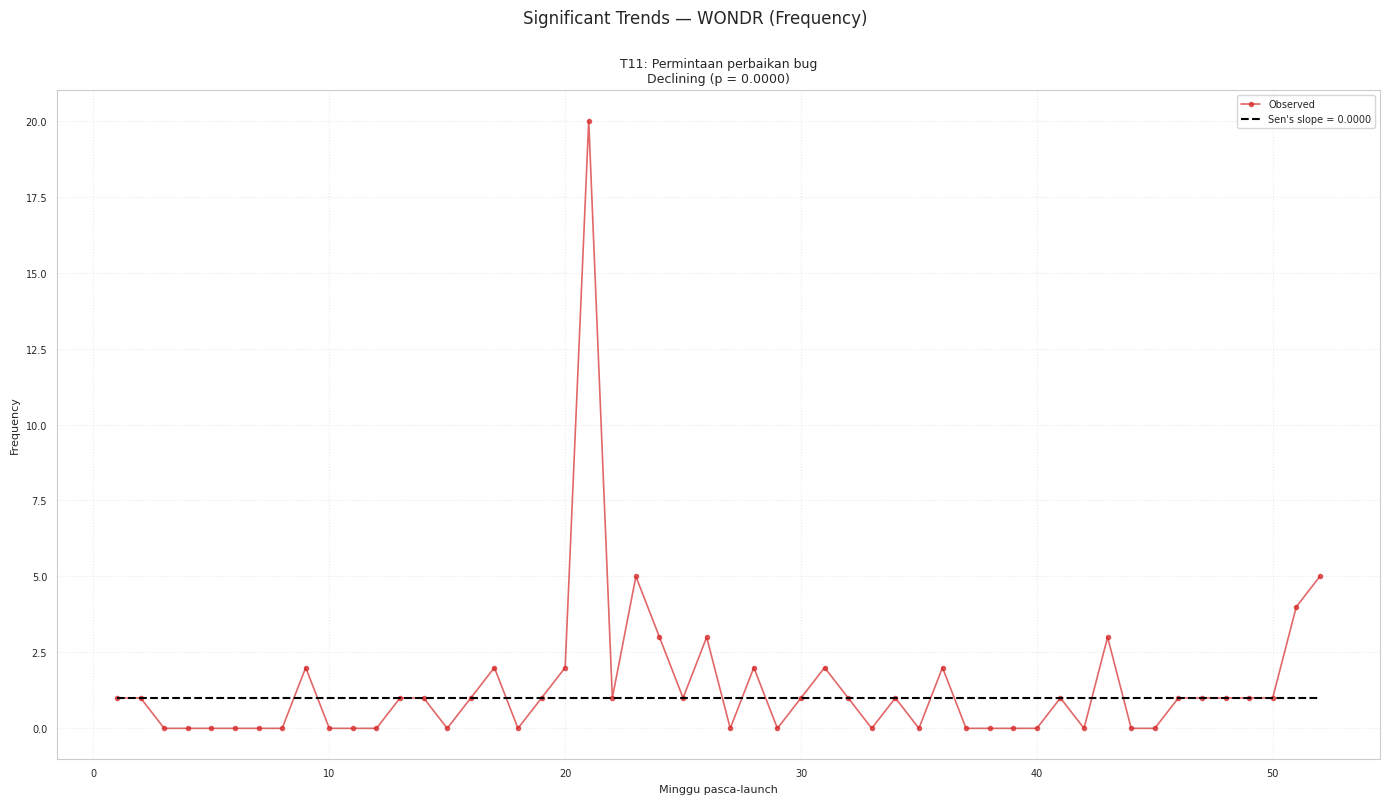

In [58]:
# Lineplot: frequency (significant only)
fig_sig_freq = plot_significant_trends_lines(
    series_df=weekly_series['frequency'],
    mk_results=mk_results_freq_for_plot,
    topic_labels=TOPIC_LABELS_WONDR,
    fig_dir=FIG_DIR,
    app_name='wondr',
    series_type='frequency',
)
plt.show()

## Section 10.5 — T11 Numerical Edge Case Fix

**Anomali:** T11 'Permintaan perbaikan bug' di **frequency series** punya `Sen_slope = 0.0000` tapi MK test signifikan declining. Numerical edge case karena banyak weeks bernilai 0/1, membuat median pairwise slope = 0 padahal S statistic slightly negative.

**Solution:** Tambah 2 kolom di `wondr_mk_frequency.csv`:
1. `Practically_Stable` — flag boolean: `|Sen_slope| < EPSILON AND Significant_FDR == True`
2. `Classification_FDR_final` — versi clean: kalau practically_stable, override ke `'Stable (practically)'`

**EPSILON = 1e-6** — robust terhadap floating point noise tanpa misclassify slope kecil yang valid (orde 1e-4 ke atas).

**Cross-check:** Proportion series CLEAN (no anomali). Konsisten dengan finding handoff v9 — anomali ini artifact dari frequency series only (banyak zero-week di topic dengan total N kecil).

### 10.5.1 Apply practically_stable flag ke frequency results

In [59]:
# Re-load MK frequency results
df_mk_freq = pd.read_csv(TABLE_DIR / "wondr_mk_frequency.csv")

# Flag practically stable: Sen_slope ≈ 0 AND significant
EPSILON = 1e-6
df_mk_freq['Practically_Stable'] = (
    (df_mk_freq['Sen_slope'].abs() < EPSILON) & 
    (df_mk_freq['Significant_FDR'] == True)
)

# Override classification: kalau practically stable → "Stable (practically)"
df_mk_freq['Classification_FDR_final'] = df_mk_freq.apply(
    lambda row: 'Stable (practically)' if row['Practically_Stable'] else row['Classification_FDR'],
    axis=1
)

# Inspect
n_flagged = df_mk_freq['Practically_Stable'].sum()
print(f"Topics flagged sebagai practically stable: {n_flagged}")
print(f"\nFlagged topics:")
print(df_mk_freq[df_mk_freq['Practically_Stable']][
    ['Topic', 'Label', 'Sen_slope', 'MK_p_value_adj', 'Classification_FDR', 'Classification_FDR_final']
].to_string(index=False))

print(f"\nFinal classification distribution (frequency):")
print(df_mk_freq['Classification_FDR_final'].value_counts())

Topics flagged sebagai practically stable: 1

Flagged topics:
 Topic                    Label  Sen_slope  MK_p_value_adj Classification_FDR Classification_FDR_final
    11 Permintaan perbaikan bug        0.0        0.000328          declining     Stable (practically)

Final classification distribution (frequency):
Classification_FDR_final
stable                  12
Stable (practically)     1
Name: count, dtype: int64


### 10.5.2 Backup + save updated CSV

In [60]:
import shutil

# Backup pre-fix version
shutil.copy(
    TABLE_DIR / "wondr_mk_frequency.csv",
    TABLE_DIR / "wondr_mk_frequency_pre_t11_fix.csv"
)

# Save updated version (overwrite)
df_mk_freq.to_csv(TABLE_DIR / "wondr_mk_frequency.csv", index=False)
print("✓ Saved: outputs/tables/wondr_mk_frequency.csv (T11 anomali handled)")
print("✓ Backup: outputs/tables/wondr_mk_frequency_pre_t11_fix.csv")

✓ Saved: outputs/tables/wondr_mk_frequency.csv (T11 anomali handled)
✓ Backup: outputs/tables/wondr_mk_frequency_pre_t11_fix.csv


### 10.5.3 Cross-check: anomali di proportion series?

In [61]:
df_mk_prop = pd.read_csv(TABLE_DIR / "wondr_mk_proportion.csv")
df_mk_prop['Practically_Stable'] = (
    (df_mk_prop['Sen_slope'].abs() < EPSILON) & 
    (df_mk_prop['Significant_FDR'] == True)
)

n_flagged_prop = df_mk_prop['Practically_Stable'].sum()
print(f"Proportion series — topics flagged: {n_flagged_prop}")
if n_flagged_prop > 0:
    print(df_mk_prop[df_mk_prop['Practically_Stable']][
        ['Topic', 'Label', 'Sen_slope', 'MK_p_value_adj', 'Classification_FDR']
    ])
else:
    print("✓ Proportion series clean, no anomali.")
    print("  Konsisten dengan finding handoff v9 (T11 anomali only di frequency series).")

Proportion series — topics flagged: 0
✓ Proportion series clean, no anomali.
  Konsisten dengan finding handoff v9 (T11 anomali only di frequency series).


## Pipeline Status & Next Steps

### Wondr coding ✅ COMPLETE

Semua section (0 sampai 10.5) sudah dieksekusi dan output tersimpan di repository.

**Final outputs:**

- **Model:** `data/models/wondr_phase_c/` (13 topics, c_v=0.6964, c_npmi=0.1752)
- **DTM:** `data/processed/wondr_topics_over_time.pkl`
- **12 figures:** `outputs/figures/wondr/`
- **9 tables:** `outputs/tables/wondr_*.csv`

### Next: BYOND replication

Notebook `06_bertopic_byond.ipynb` — heavy reuse modul existing dengan parameter `app_name`. Lihat `handoff_byond_quickref.md` untuk:

- 4 decision points (stopwords refactor, embedding strategy, threshold per app, grid expansion)
- Step-by-step plan 4 sesi
- Setup cells siap-paste

### Outstanding (defer ke phase BAB 4 drafting)

- Update `outputs/draft_section9_findings.md` — masih threshold lama
- FDR-BH metodologi paragraf untuk BAB 3
- T11 anomali narrative untuk BAB 4
- Integrated wondr findings narrative untuk BAB 4
- Cosmetic: capitalization inconsistency `'stable'` vs `'Stable (practically)'` di frequency CSV